# Labs 5 - Qunatum Furier Transform

Mateusz Tabaszewski 151945

## Introduction

The Quantum Fourier Transform (QFT) is a fundamental quantum algorithm that maps quantum states from the computational basis to the Fourier (phase) basis. It is the quantum analogue of the classical discrete Fourier transform and plays a key role in many quantum algorithms, such as Shor’s factoring algorithm. In this laboratory, the QFT is implemented using Hadamard and controlled phase rotation gates, and its action is analyzed by visualizing the resulting quantum states and verifying the inverse transformation. This lab seeks to implement and test the QFT for a simulator.

## Imports

In [1]:
from numpy import pi

# importing Qiskit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, plot_bloch_multivector
import matplotlib.pyplot as plt

## Functions

In [2]:
def encode_qunatum(bit_val):
    qc = QuantumCircuit(len(bit_val))
    for idx, bit in enumerate(bit_val[::-1]):
        if bit == "1":
            qc.x(idx)
    return qc


def get_state_bloch(qc):
    sim = Aer.get_backend("aer_simulator")
    qc_init = qc.copy()
    qc_init.save_statevector()
    statevector = sim.run(qc_init).result().get_statevector()
    return statevector

### QFT

In [3]:
def qft_recursive_angle(qc, k, j):
    if k >= 0:
        angle = pi / (2 ** (j - k))
        qc.cp(angle, k, j)
        return qft_recursive_angle(qc, k - 1, j)
    else:
        return qc


def qft_recursive_swap(qc, i, n):
    if i < n // 2:
        qc.swap(i, n - i - 1)
        return qft_recursive_swap(qc, i + 1, n)
    else:
        return qc


def qft_recursive_call(qc, n):
    if n == 0:
        return qc
    else:
        j = n - 1
        qc.h(j)
        qc = qft_recursive_angle(qc, j - 1, j)
    return qft_recursive_call(qc, n - 1)


def qft_recursive(qc, n):
    qc = qft_recursive_call(qc, n)
    qc = qft_recursive_swap(qc, 0, n)
    return qc


def qft(qc, n):
    for j in range(n - 1, -1, -1):
        qc.h(j)
        for k in range(j - 1, -1, -1):
            angle = pi / (2 ** (j - k))
            qc.cp(angle, k, j)

    for i in range(n // 2):
        qc.swap(i, n - i - 1)
    return qc

### IQFT

In [4]:
def iqft_recursive_angle(qc, k, j):
    if k >= 0:
        angle = -1 * pi / (2 ** (j - k))
        qc.cp(angle, k, j)
        return iqft_recursive_angle(qc, k - 1, j)
    else:
        return qc


def iqft_recursive_call(qc, j, n):
    if j >= n:
        return qc
    else:
        qc = iqft_recursive_angle(qc, j - 1, j)
        qc.h(j)
    return iqft_recursive_call(qc, j + 1, n)


def iqft_recursive(qc, n):
    qc = qft_recursive_swap(qc, 0, n)
    qc = iqft_recursive_call(qc, 0, n)
    return qc


def iqft(qc, n):
    for i in range(n // 2):
        qc.swap(i, n - i - 1)

    for j in range(n):
        for k in range(j - 1, -1, -1):
            angle = -1 * pi / (2 ** (j - k))
            qc.cp(angle, k, j)
        qc.h(j)
    return qc

### Entire Experiment

In [5]:
def run_experiment(n):
    results = {}
    for i in range(2**n):
        value = f"{i:03b}"
        qc = encode_qunatum(value)
        qc = qft_recursive(qc, n)
        statevector = get_state_bloch(qc)
        qc = iqft_recursive(qc, n)
        qc.measure_all()
        backend = Aer.get_backend("qasm_simulator")
        shots = 2048
        transpiled_qc = transpile(qc, backend, optimization_level=3)
        job = backend.run(transpiled_qc, shots=shots)
        counts = job.result().get_counts()
        results[value] = [statevector, counts]
    return results

## Task 1 - |100>

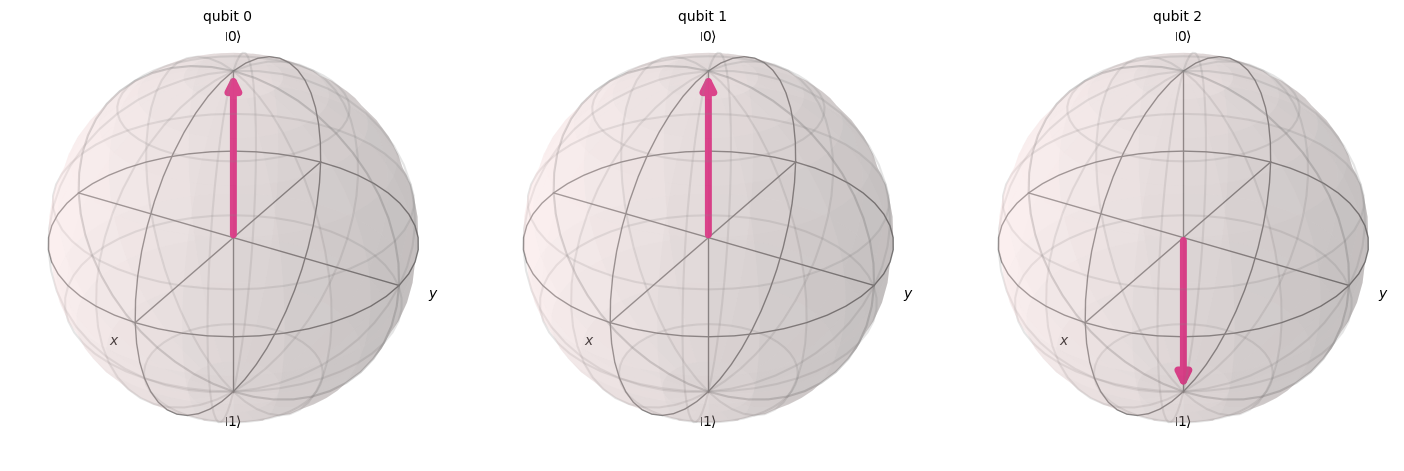

In [6]:
qc = encode_qunatum("100")
statevector = get_state_bloch(qc)
plot_bloch_multivector(statevector)

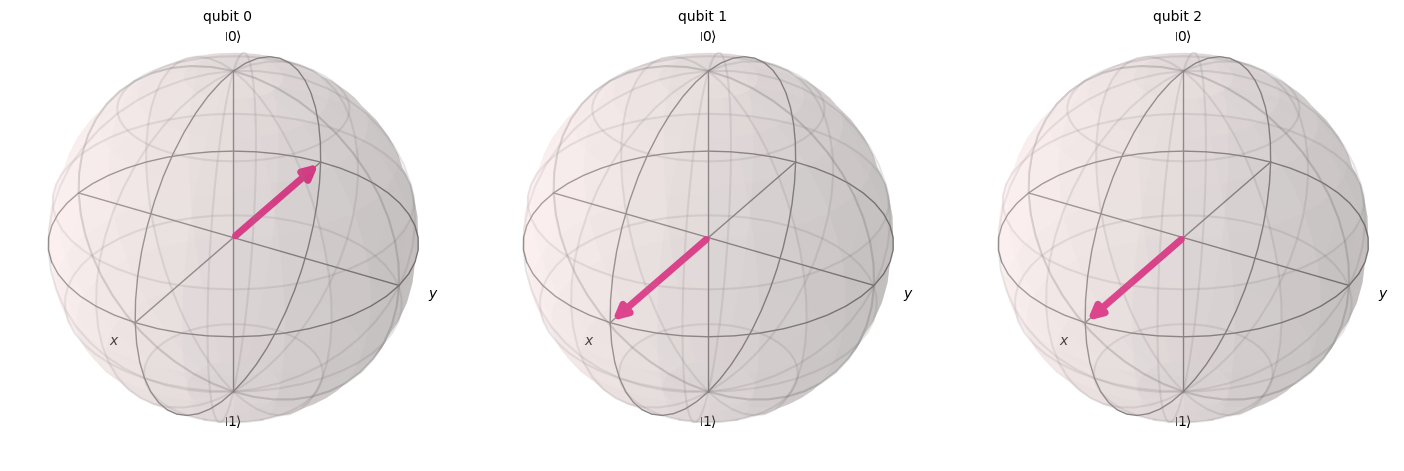

In [7]:
qc = qft_recursive(qc, 3)
statevector = get_state_bloch(qc)
plot_bloch_multivector(statevector)

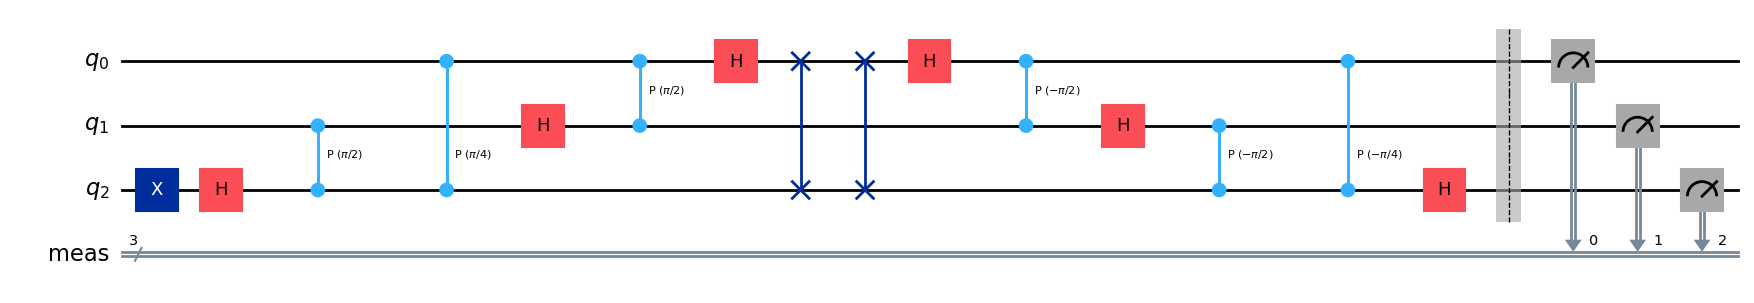

In [8]:
qc = iqft_recursive(qc, 3)
qc.measure_all()
qc.draw("mpl")

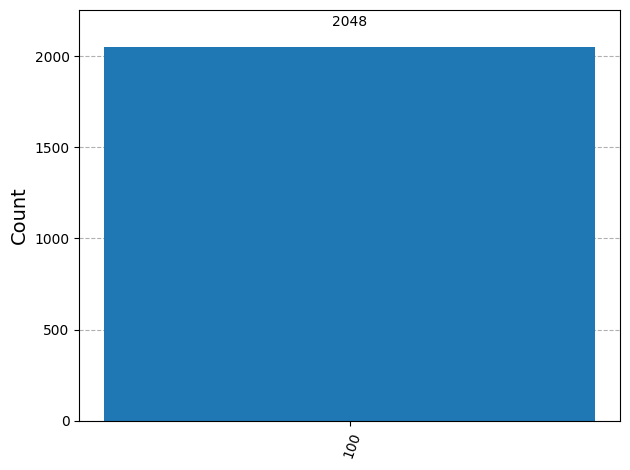

In [9]:
backend = Aer.get_backend("qasm_simulator")
shots = 2048
transpiled_qc = transpile(qc, backend, optimization_level=3)
job = backend.run(transpiled_qc, shots=shots)
counts = job.result().get_counts()
plot_histogram(counts)

## Task 2 - |011>

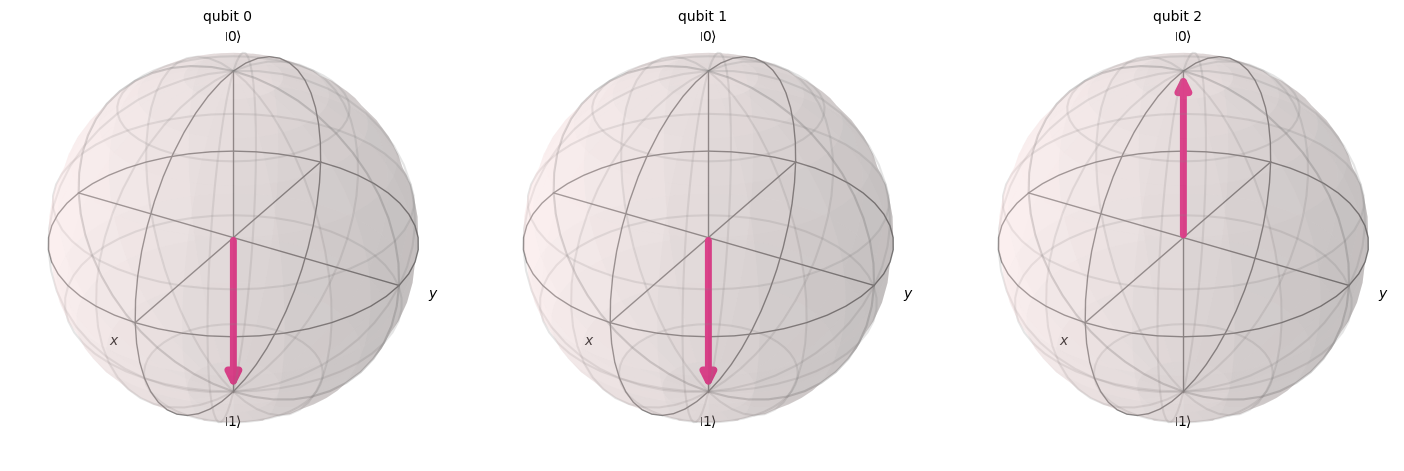

In [10]:
qc = encode_qunatum("011")
statevector = get_state_bloch(qc)
plot_bloch_multivector(statevector)

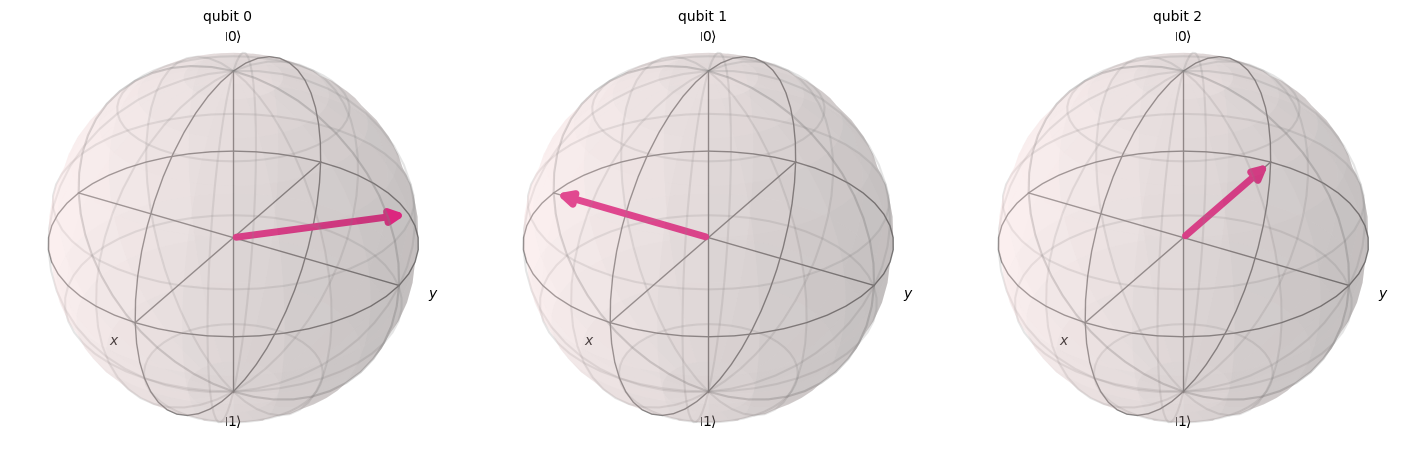

In [11]:
qc = qft_recursive(qc, 3)
statevector = get_state_bloch(qc)
plot_bloch_multivector(statevector)

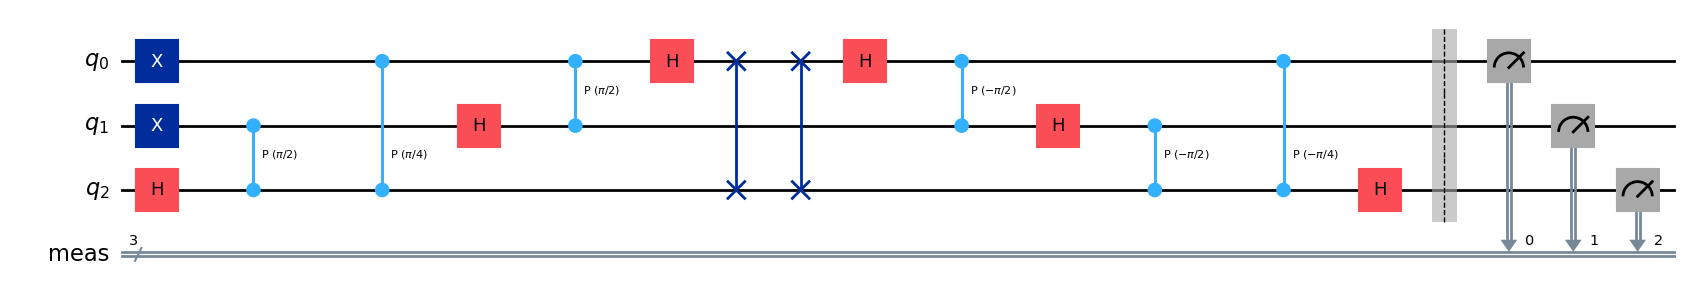

In [12]:
qc = iqft_recursive(qc, 3)
qc.measure_all()
qc.draw("mpl")

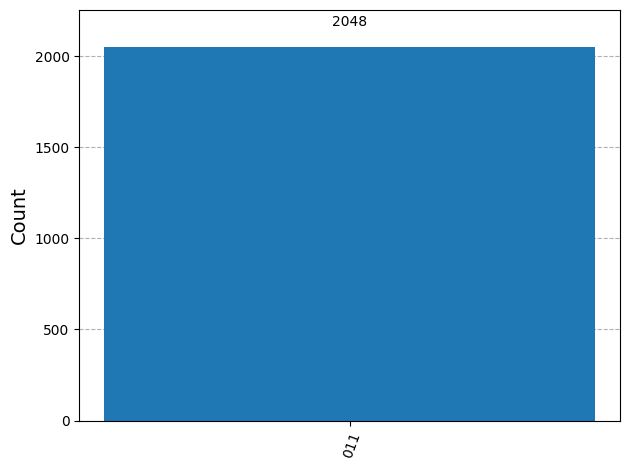

In [13]:
backend = Aer.get_backend("qasm_simulator")
shots = 2048
transpiled_qc = transpile(qc, backend, optimization_level=3)
job = backend.run(transpiled_qc, shots=shots)
counts = job.result().get_counts()
plot_histogram(counts)

## Task 3 - Bloch Spheres for all n=3 qubits

In [14]:
results = run_experiment(3)

### 000

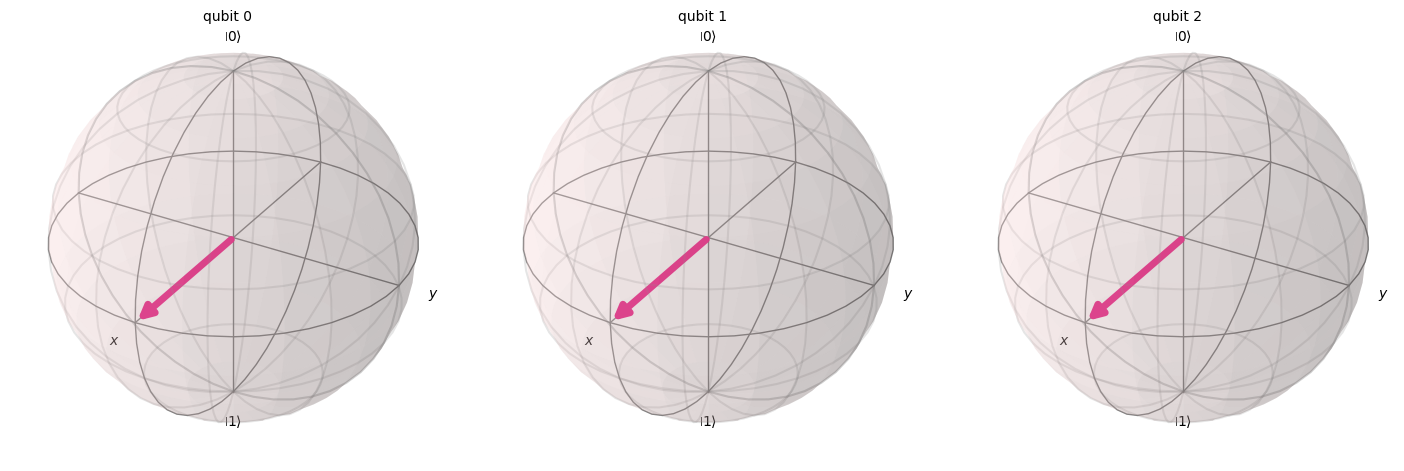

In [15]:
statevec, counts = results["000"]
plot_bloch_multivector(statevec)

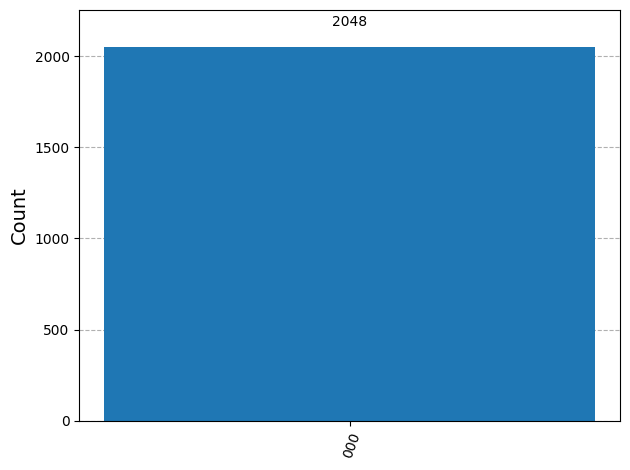

In [16]:
plot_histogram(counts)

### 001

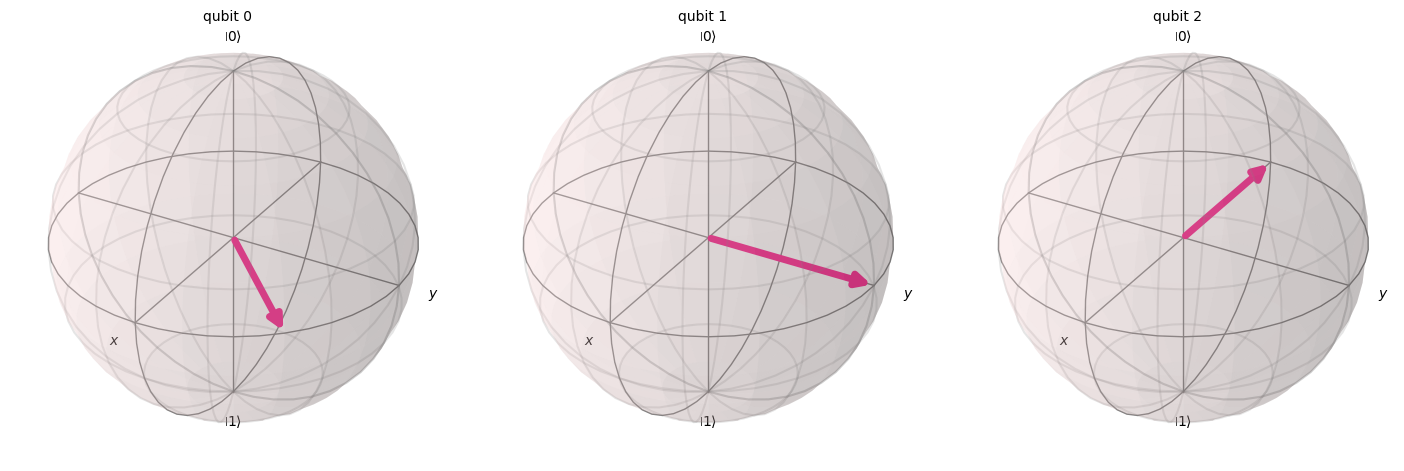

In [17]:
statevec, counts = results["001"]
plot_bloch_multivector(statevec)

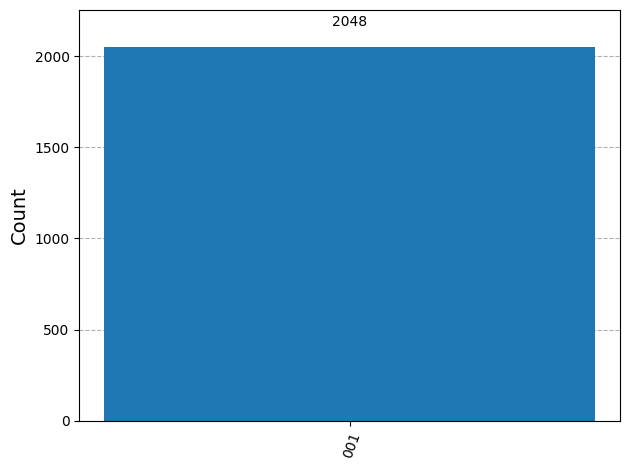

In [18]:
plot_histogram(counts)

### 010

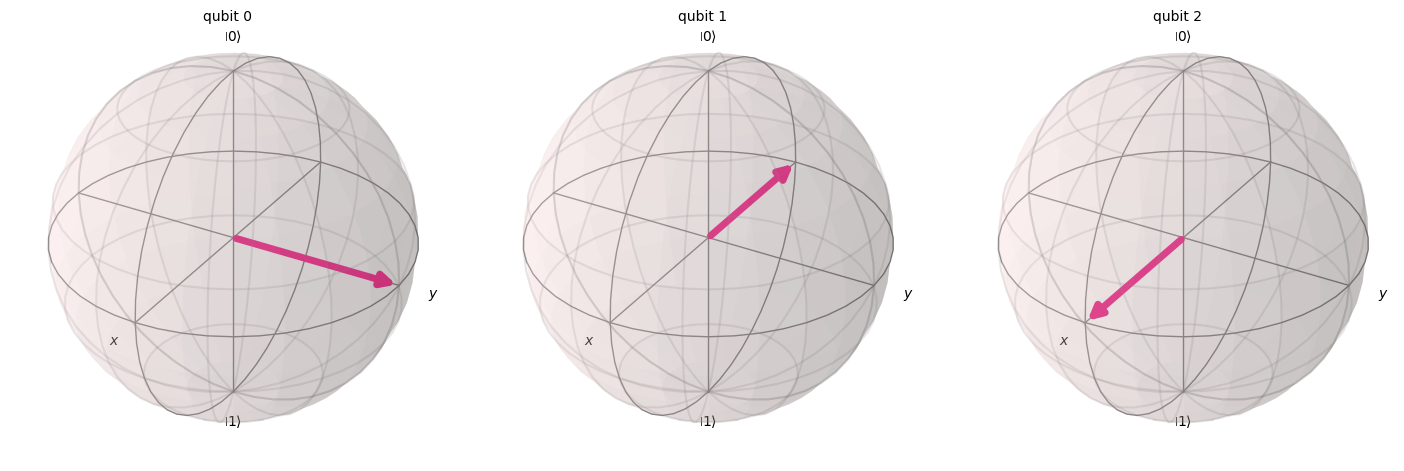

In [19]:
statevec, counts = results["010"]
plot_bloch_multivector(statevec)

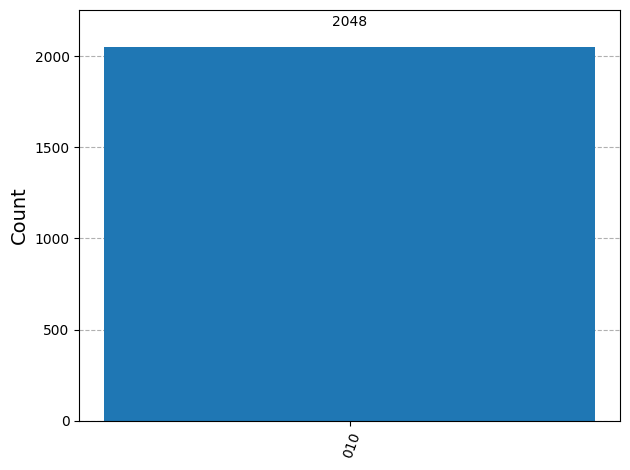

In [20]:
plot_histogram(counts)

### 011

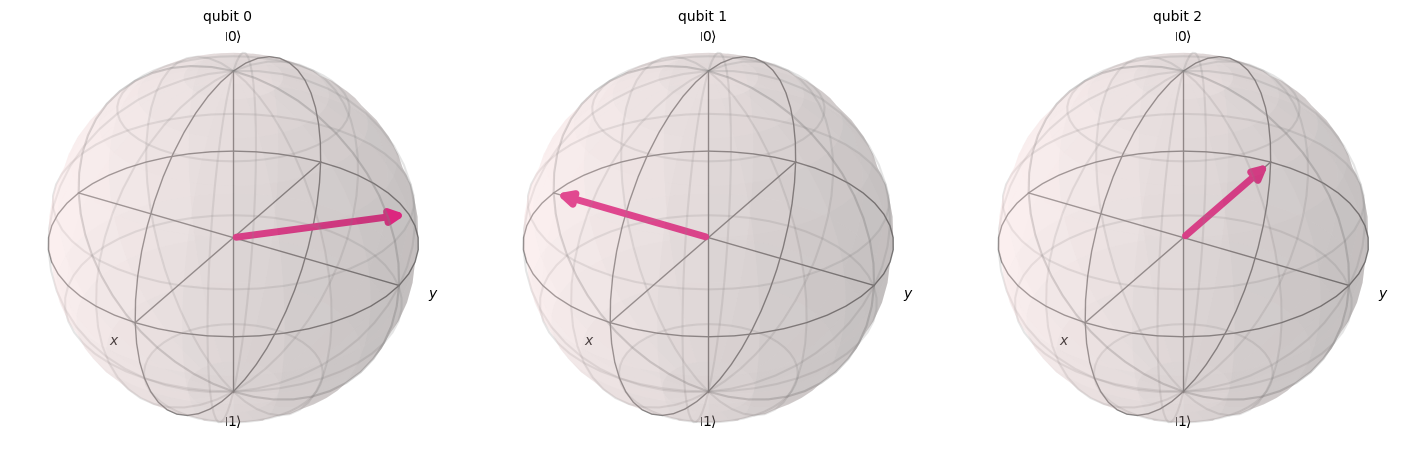

In [21]:
statevec, counts = results["011"]
plot_bloch_multivector(statevec)

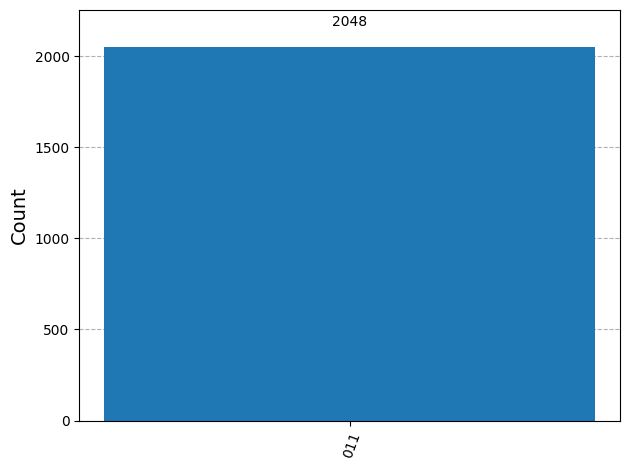

In [22]:
plot_histogram(counts)

### 100

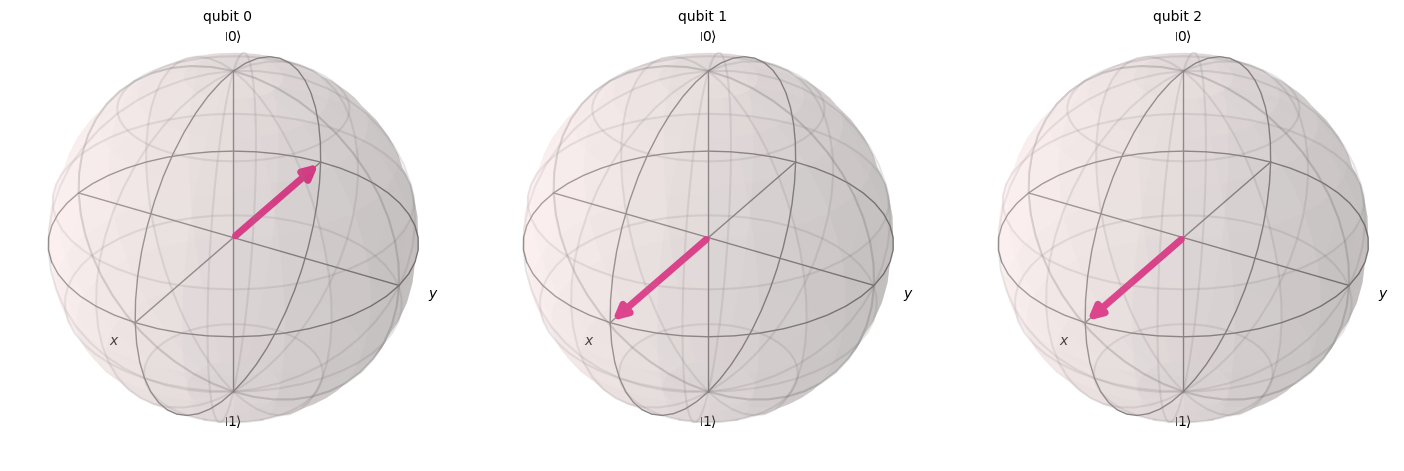

In [23]:
statevec, counts = results["100"]
plot_bloch_multivector(statevec)

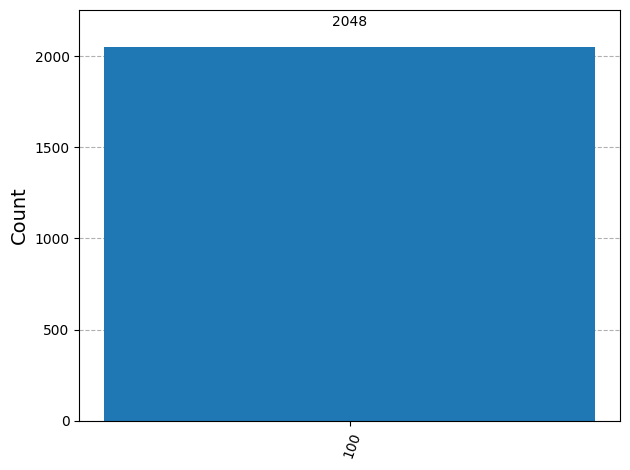

In [24]:
plot_histogram(counts)

### 101

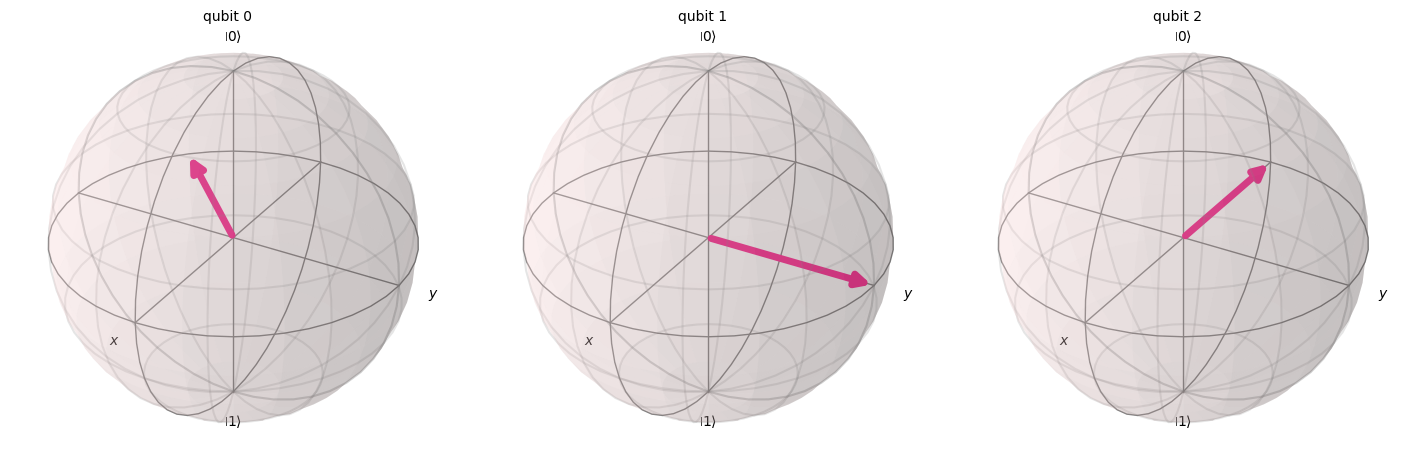

In [25]:
statevec, counts = results["101"]
plot_bloch_multivector(statevec)

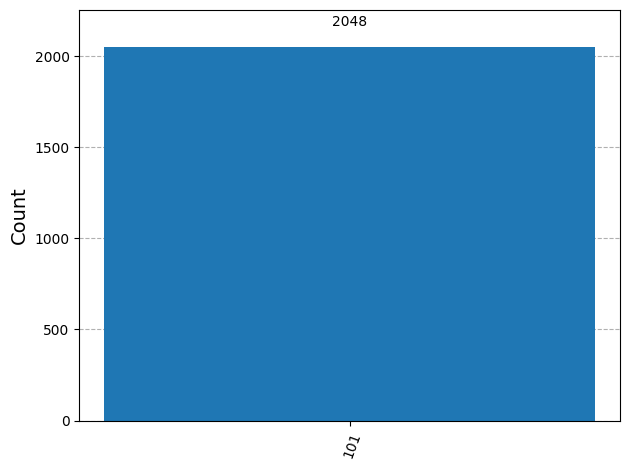

In [26]:
plot_histogram(counts)

### 110

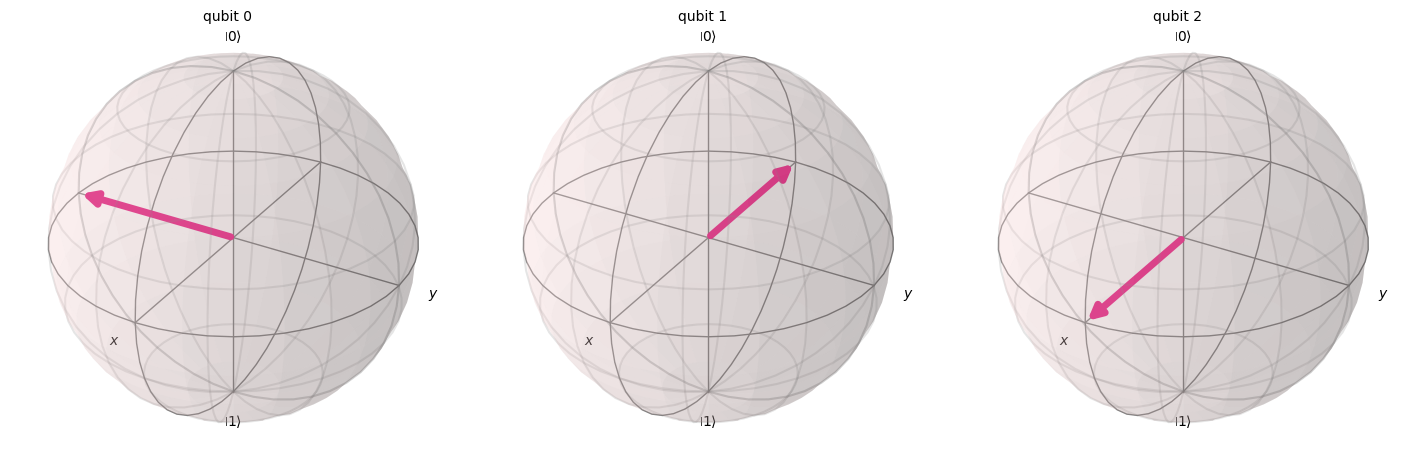

In [27]:
statevec, counts = results["110"]
plot_bloch_multivector(statevec)

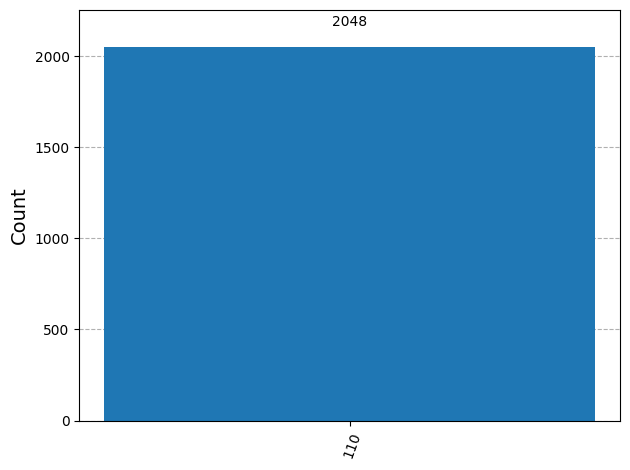

In [28]:
plot_histogram(counts)

### 111

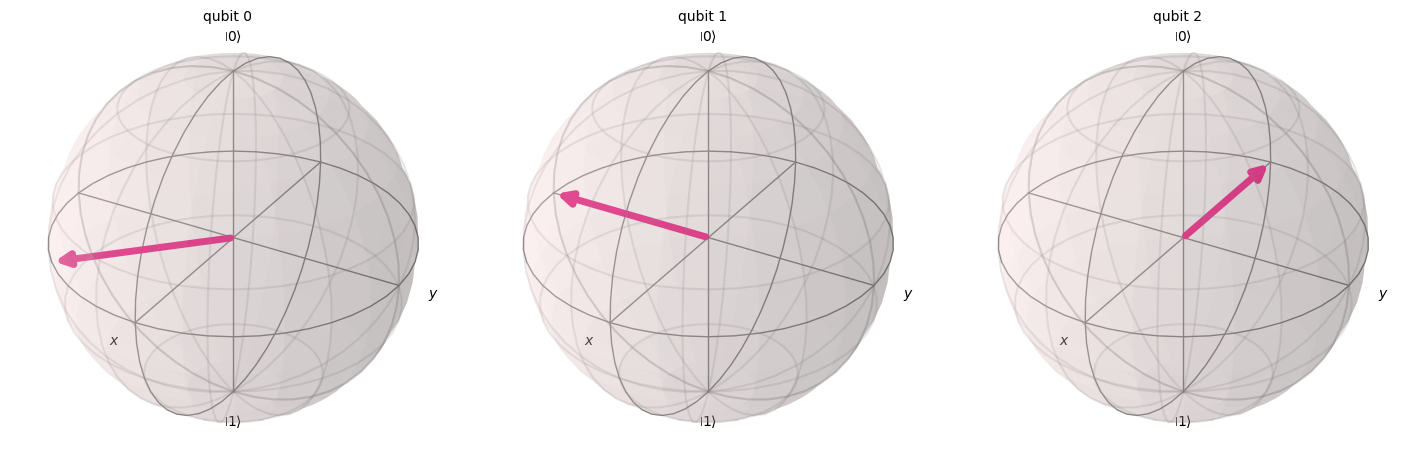

In [29]:
statevec, counts = results["111"]
plot_bloch_multivector(statevec)

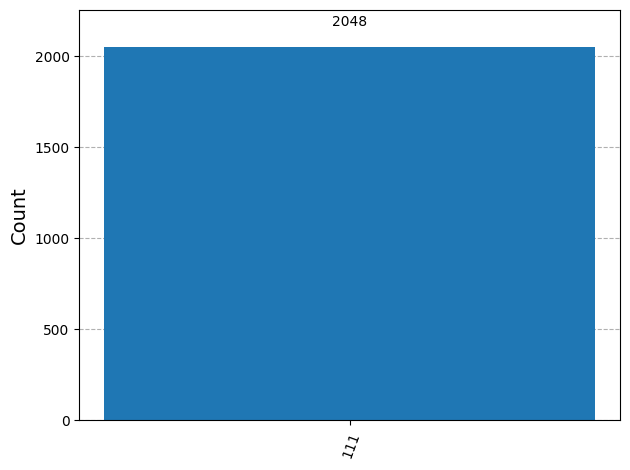

In [30]:
plot_histogram(counts)

## Task 4

### Qubit |1>

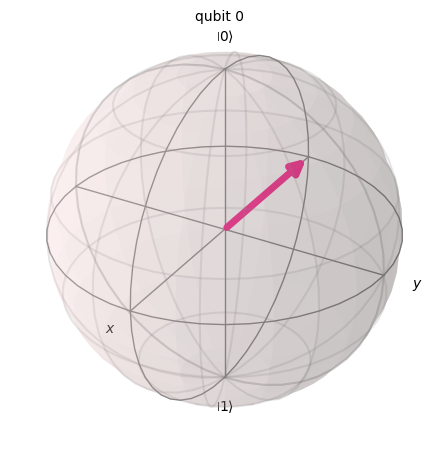

In [31]:
val = "1"
qc = encode_qunatum(val)
qc = qft_recursive(qc, len(val))
statevector = get_state_bloch(qc)
plot_bloch_multivector(statevector)

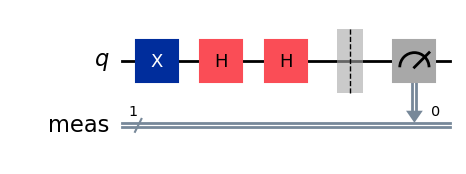

In [32]:
qc = iqft_recursive(qc, len(val))
qc.measure_all()
qc.draw("mpl")

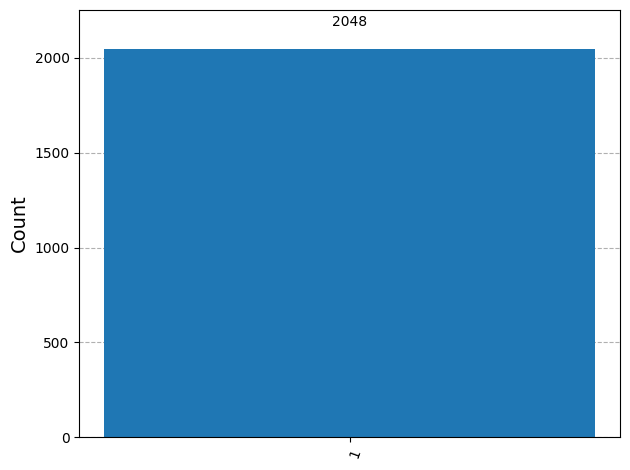

In [33]:
backend = Aer.get_backend("qasm_simulator")
shots = 2048
transpiled_qc = transpile(qc, backend, optimization_level=3)
job = backend.run(transpiled_qc, shots=shots)
counts = job.result().get_counts()
plot_histogram(counts)

### Qubit |10>

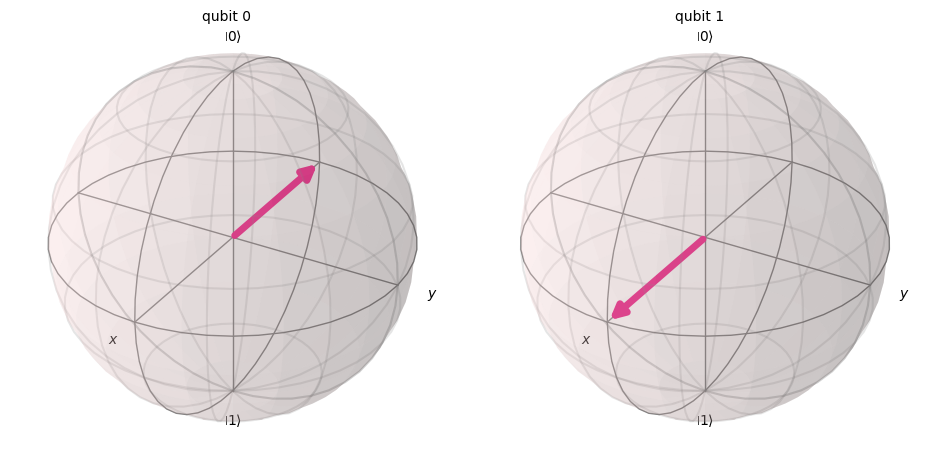

In [34]:
val = "10"
qc = encode_qunatum(val)
qc = qft_recursive(qc, len(val))
statevector = get_state_bloch(qc)
plot_bloch_multivector(statevector)

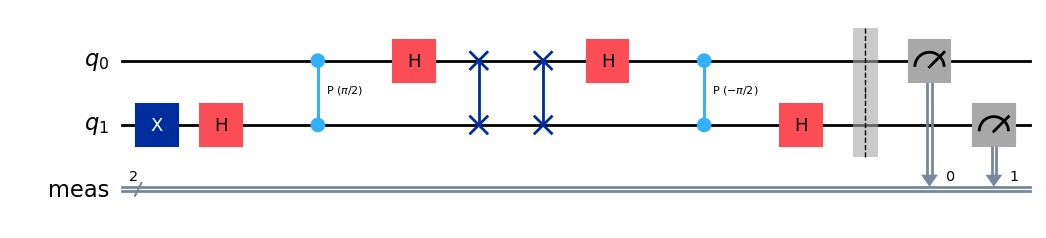

In [35]:
qc = iqft_recursive(qc, len(val))
qc.measure_all()
qc.draw("mpl")

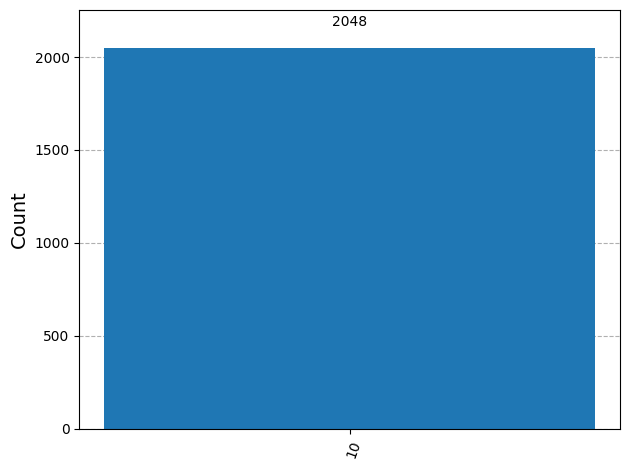

In [36]:
backend = Aer.get_backend("qasm_simulator")
shots = 2048
transpiled_qc = transpile(qc, backend, optimization_level=3)
job = backend.run(transpiled_qc, shots=shots)
counts = job.result().get_counts()
plot_histogram(counts)

### Qubit |101>

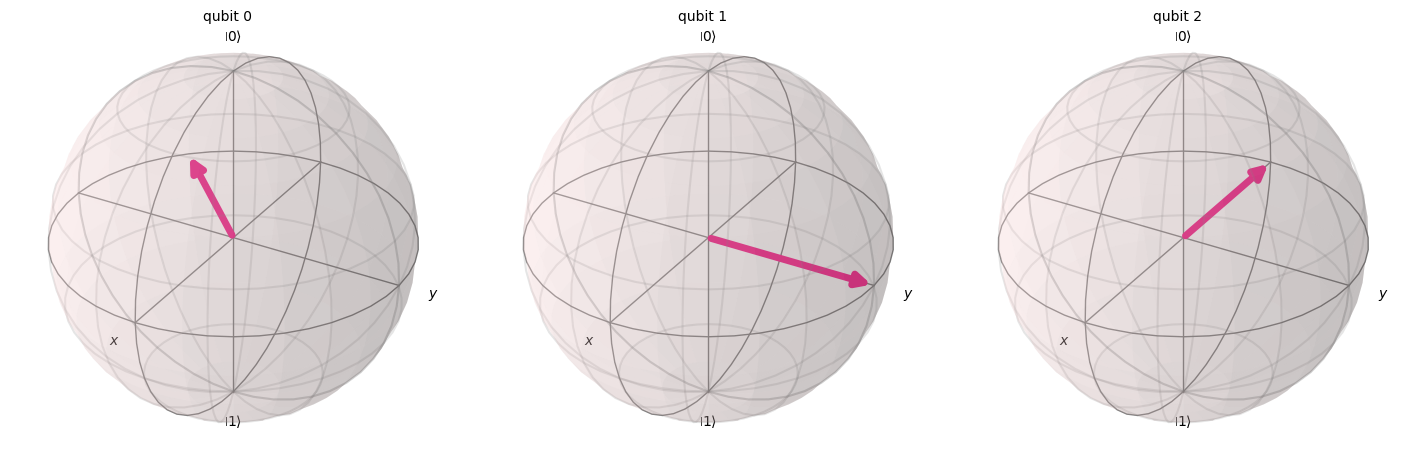

In [37]:
val = "101"
qc = encode_qunatum(val)
qc = qft_recursive(qc, len(val))
statevector = get_state_bloch(qc)
plot_bloch_multivector(statevector)

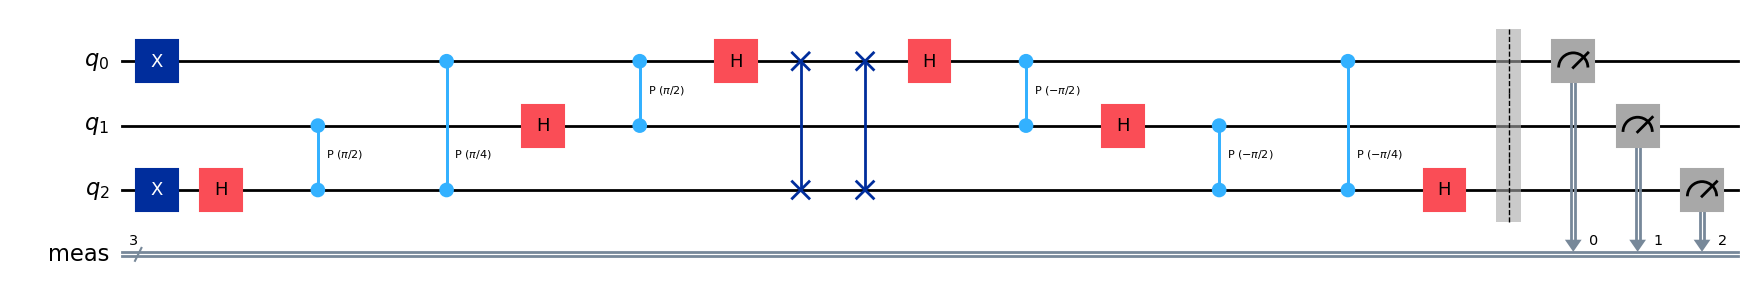

In [38]:
qc = iqft_recursive(qc, len(val))
qc.measure_all()
qc.draw("mpl")

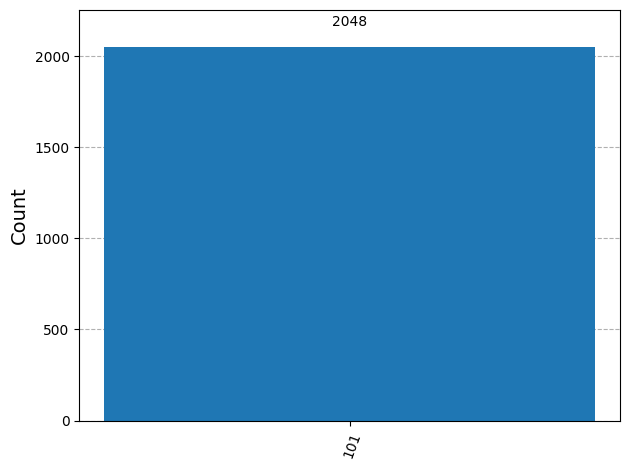

In [39]:
backend = Aer.get_backend("qasm_simulator")
shots = 2048
transpiled_qc = transpile(qc, backend, optimization_level=3)
job = backend.run(transpiled_qc, shots=shots)
counts = job.result().get_counts()
plot_histogram(counts)

### Qubit |1011>

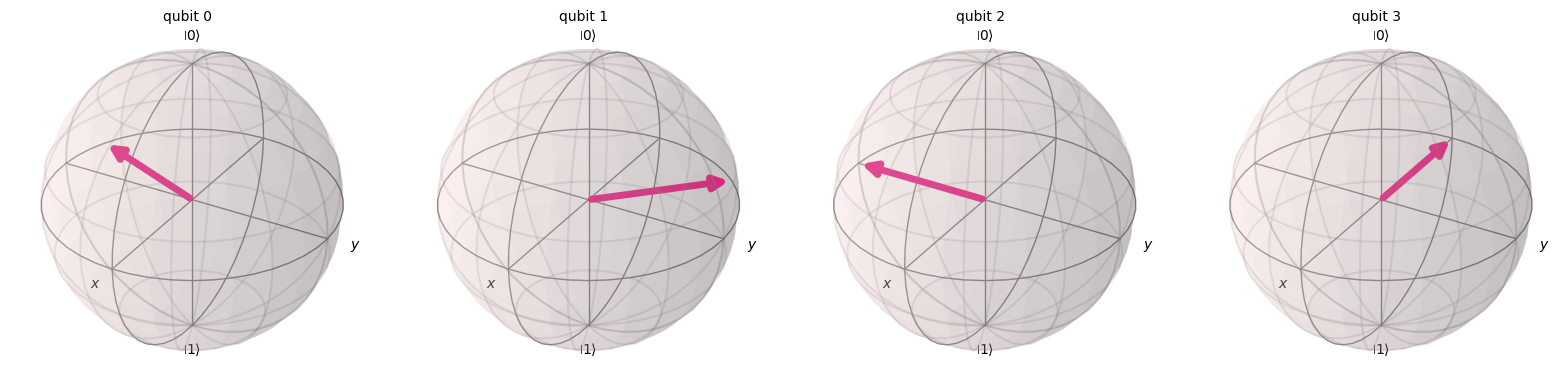

In [40]:
val = "1011"
qc = encode_qunatum(val)
qc = qft_recursive(qc, len(val))
statevector = get_state_bloch(qc)
plot_bloch_multivector(statevector)

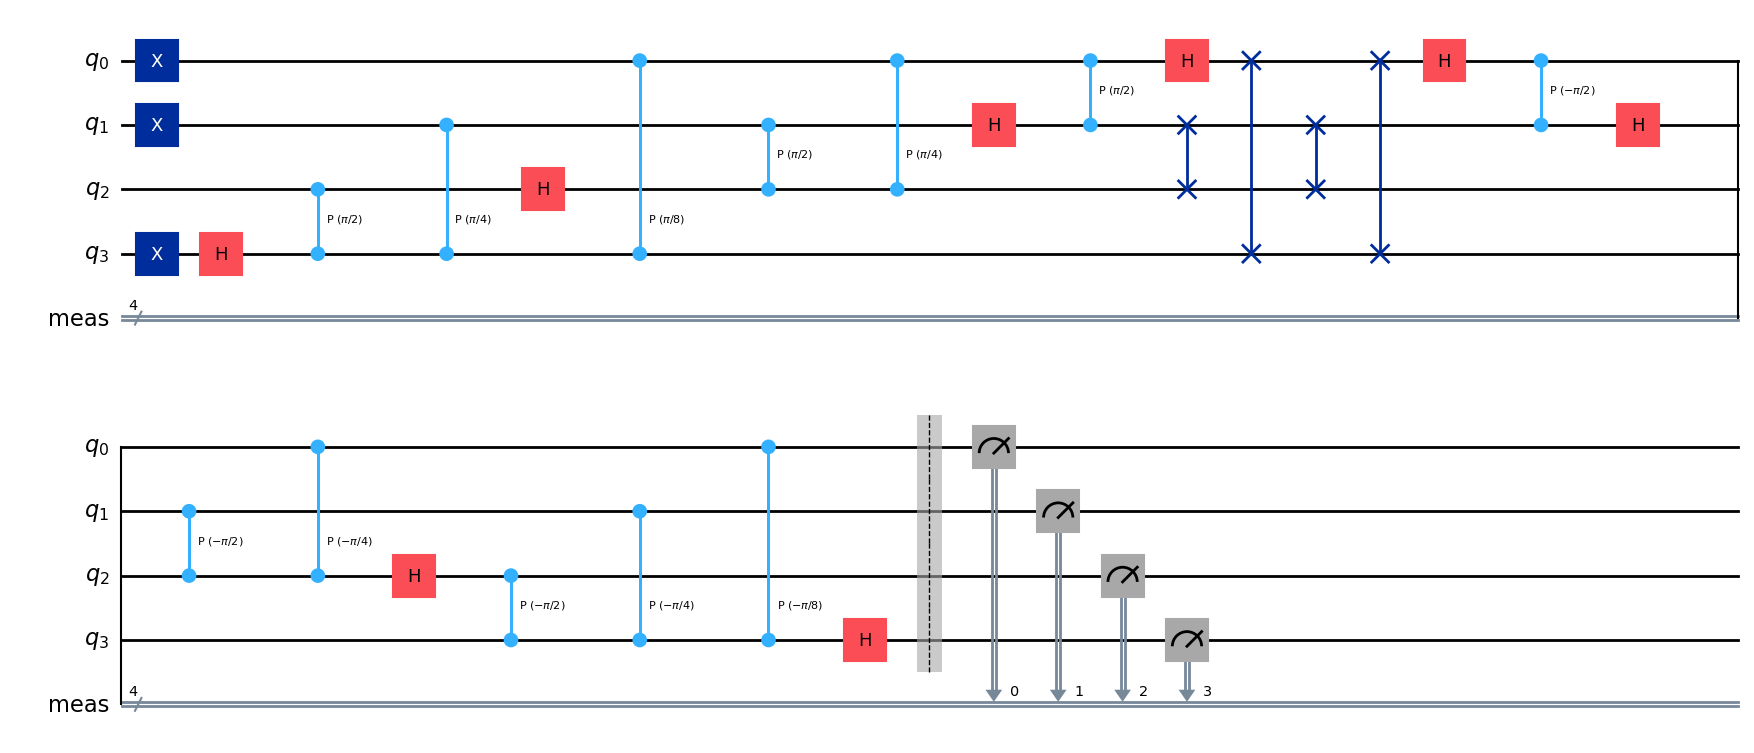

In [41]:
qc = iqft_recursive(qc, len(val))
qc.measure_all()
qc.draw("mpl")

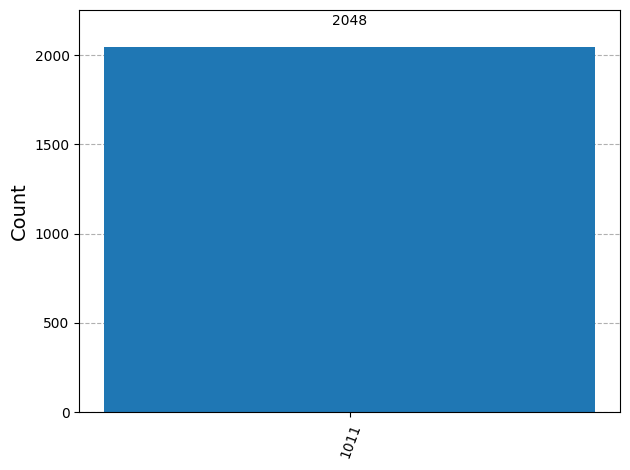

In [42]:
backend = Aer.get_backend("qasm_simulator")
shots = 2048
transpiled_qc = transpile(qc, backend, optimization_level=3)
job = backend.run(transpiled_qc, shots=shots)
counts = job.result().get_counts()
plot_histogram(counts)

### Qubit |10101>

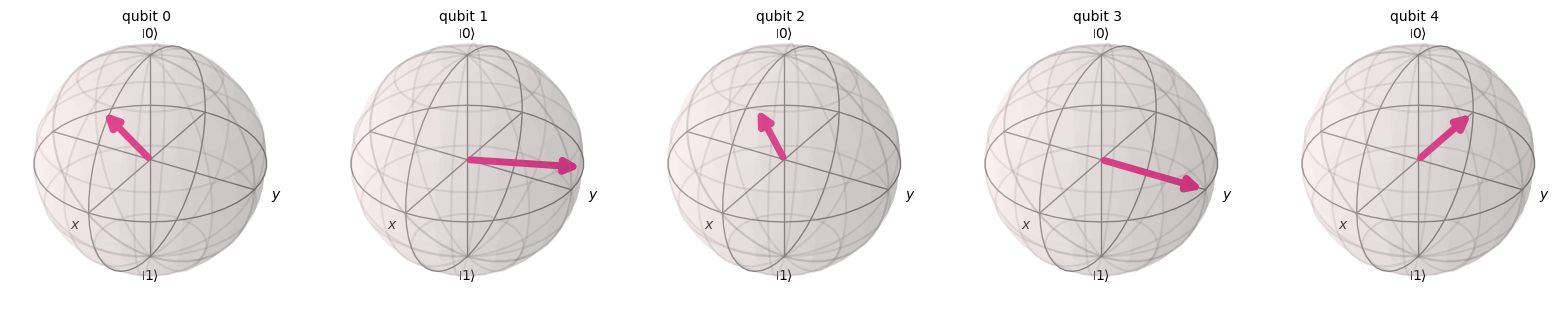

In [43]:
val = "10101"
qc = encode_qunatum(val)
qc = qft_recursive(qc, len(val))
statevector = get_state_bloch(qc)
plot_bloch_multivector(statevector)

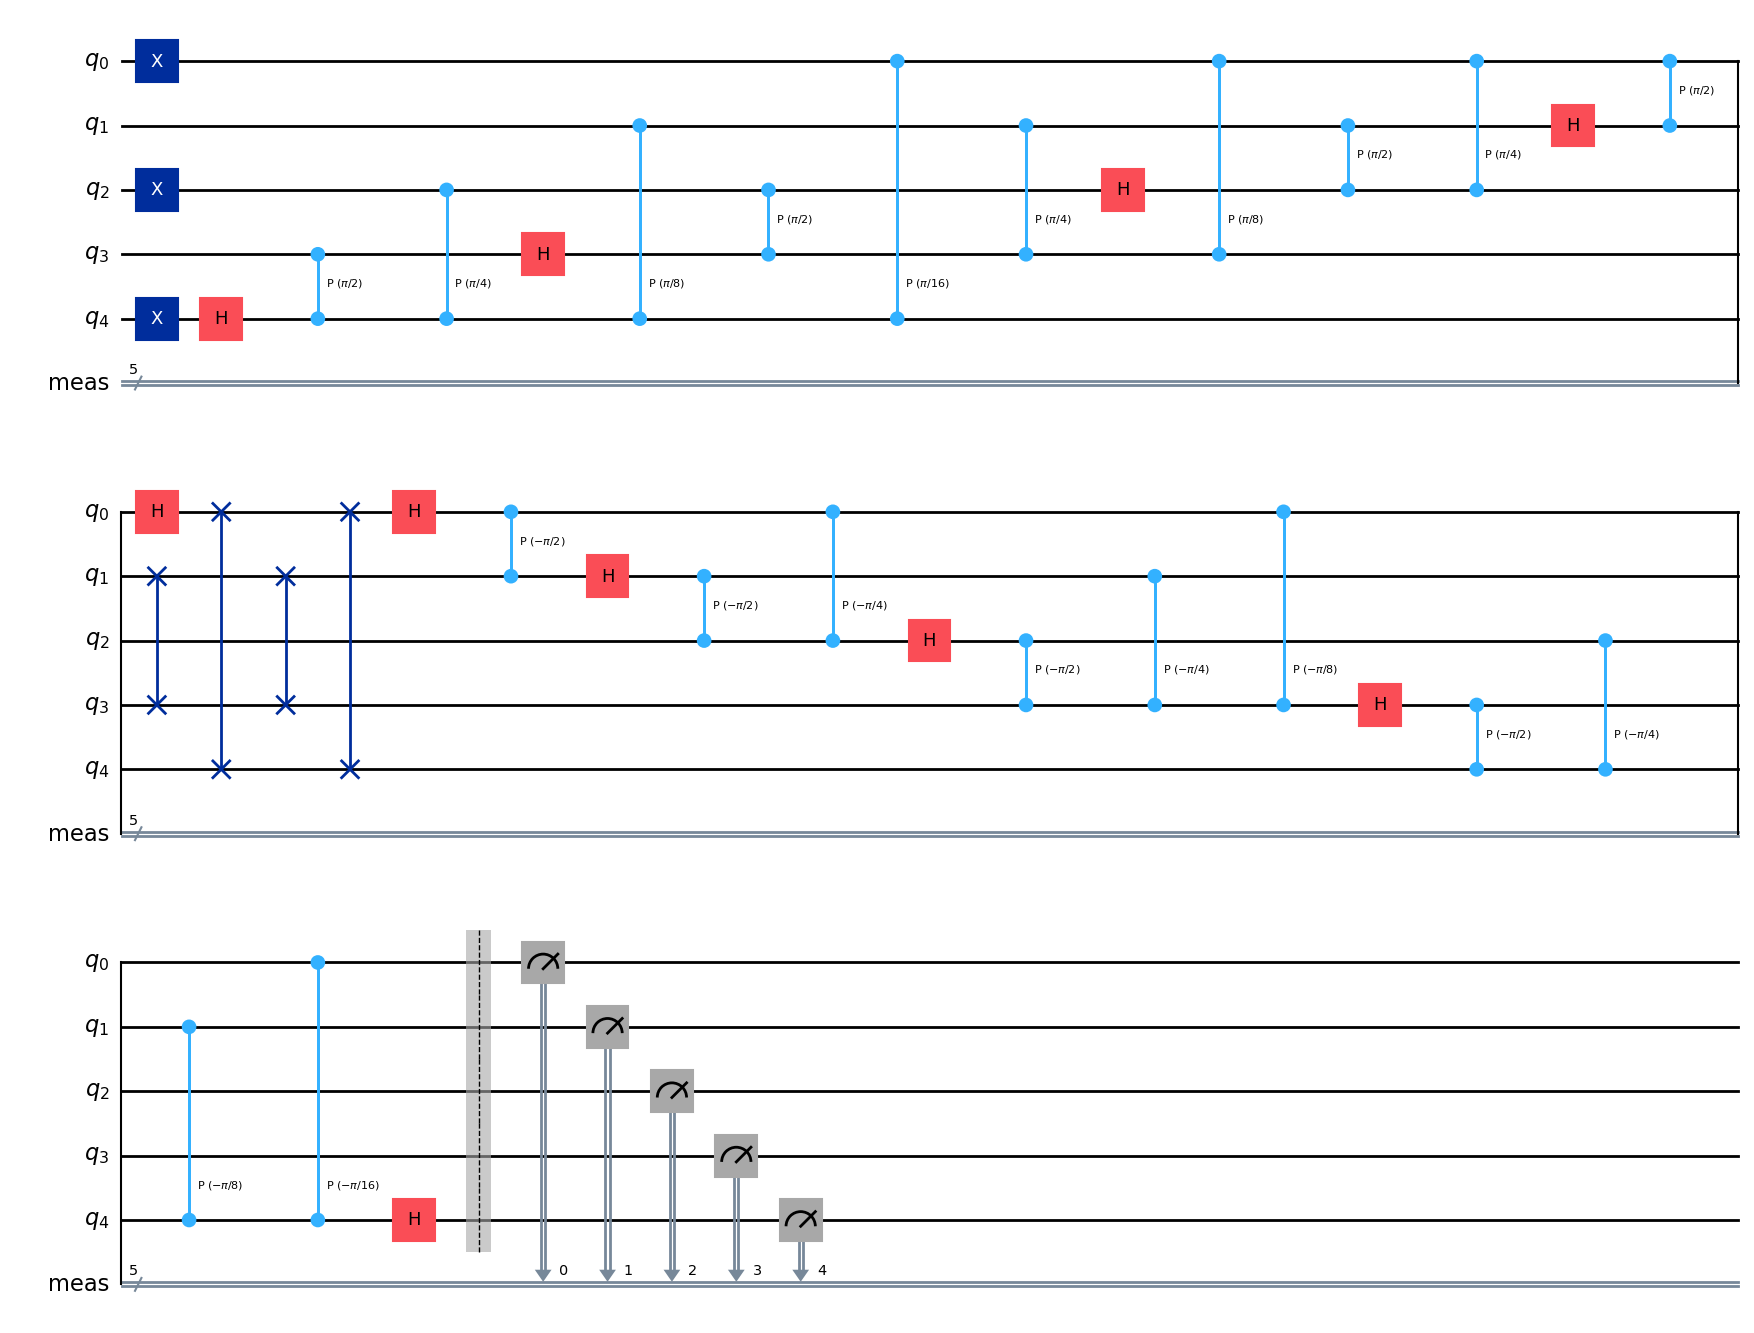

In [44]:
qc = iqft_recursive(qc, len(val))
qc.measure_all()
qc.draw("mpl")

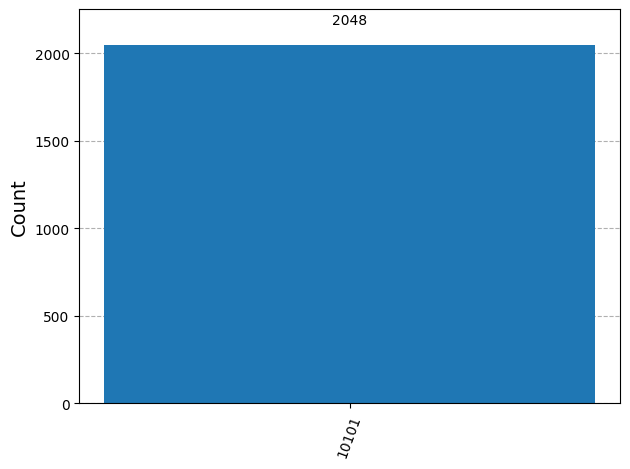

In [45]:
backend = Aer.get_backend("qasm_simulator")
shots = 2048
transpiled_qc = transpile(qc, backend, optimization_level=3)
job = backend.run(transpiled_qc, shots=shots)
counts = job.result().get_counts()
plot_histogram(counts)

### Qubit |101110>

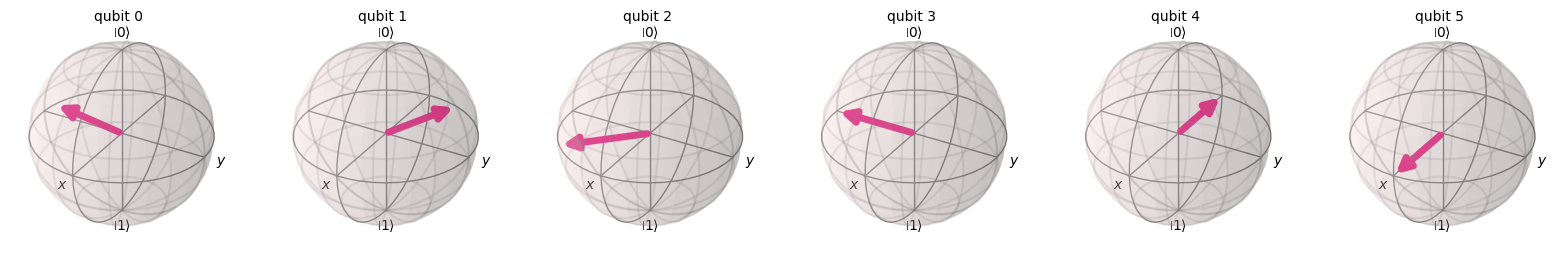

In [46]:
val = "101110"
qc = encode_qunatum(val)
qc = qft_recursive(qc, len(val))
statevector = get_state_bloch(qc)
plot_bloch_multivector(statevector)

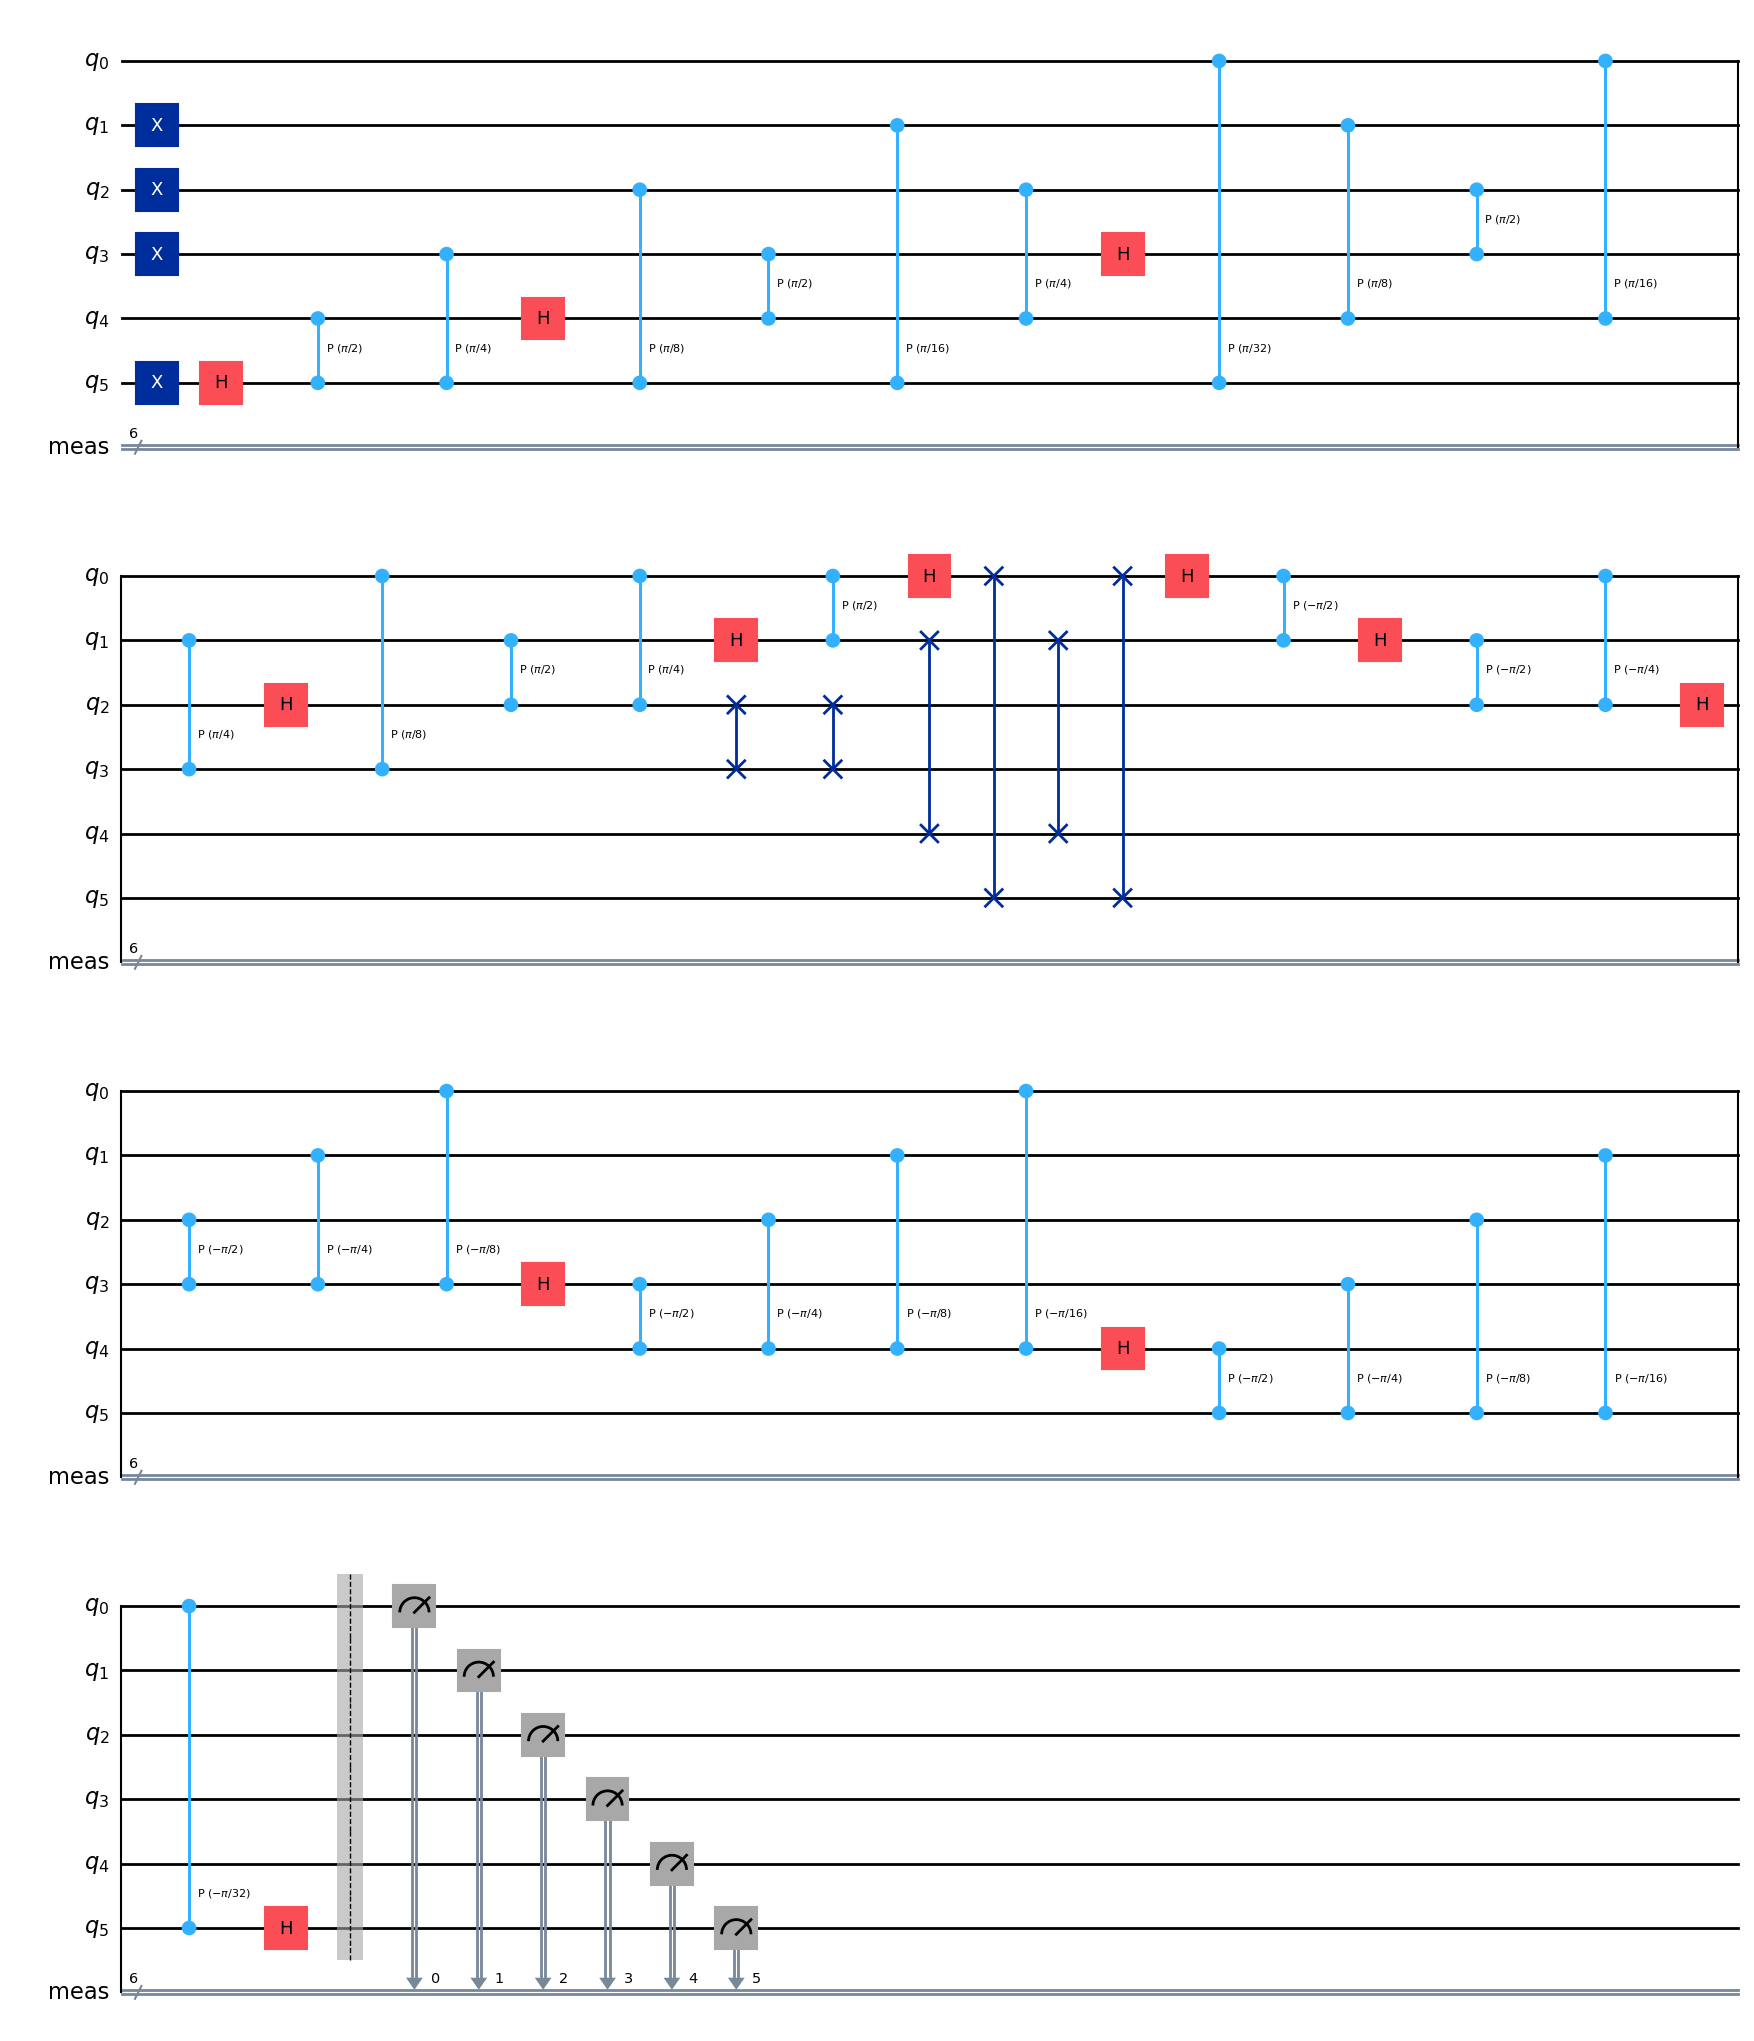

In [47]:
qc = iqft_recursive(qc, len(val))
qc.measure_all()
qc.draw("mpl")

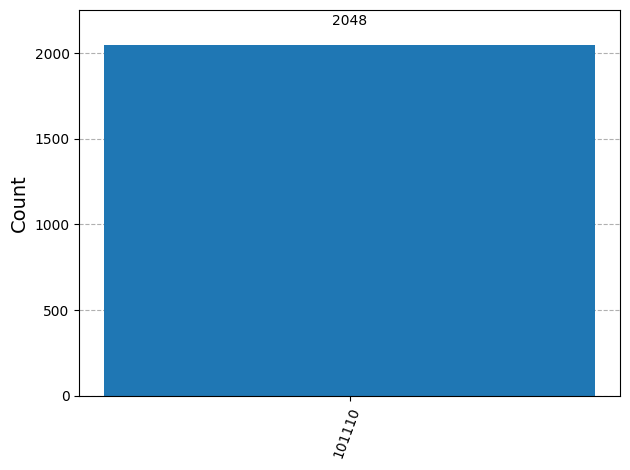

In [48]:
backend = Aer.get_backend("qasm_simulator")
shots = 2048
transpiled_qc = transpile(qc, backend, optimization_level=3)
job = backend.run(transpiled_qc, shots=shots)
counts = job.result().get_counts()
plot_histogram(counts)

### Qubit |1010101>

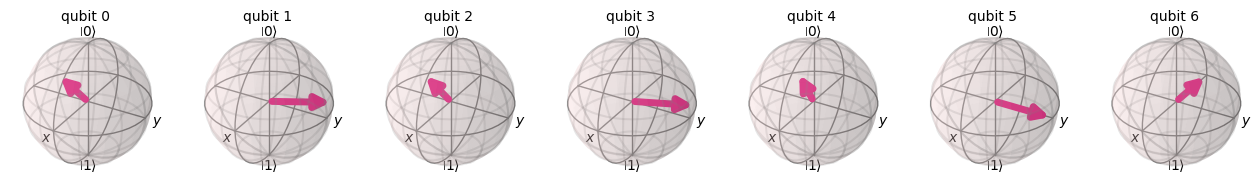

In [49]:
val = "1010101"
qc = encode_qunatum(val)
qc = qft_recursive(qc, len(val))
statevector = get_state_bloch(qc)
plot_bloch_multivector(statevector)

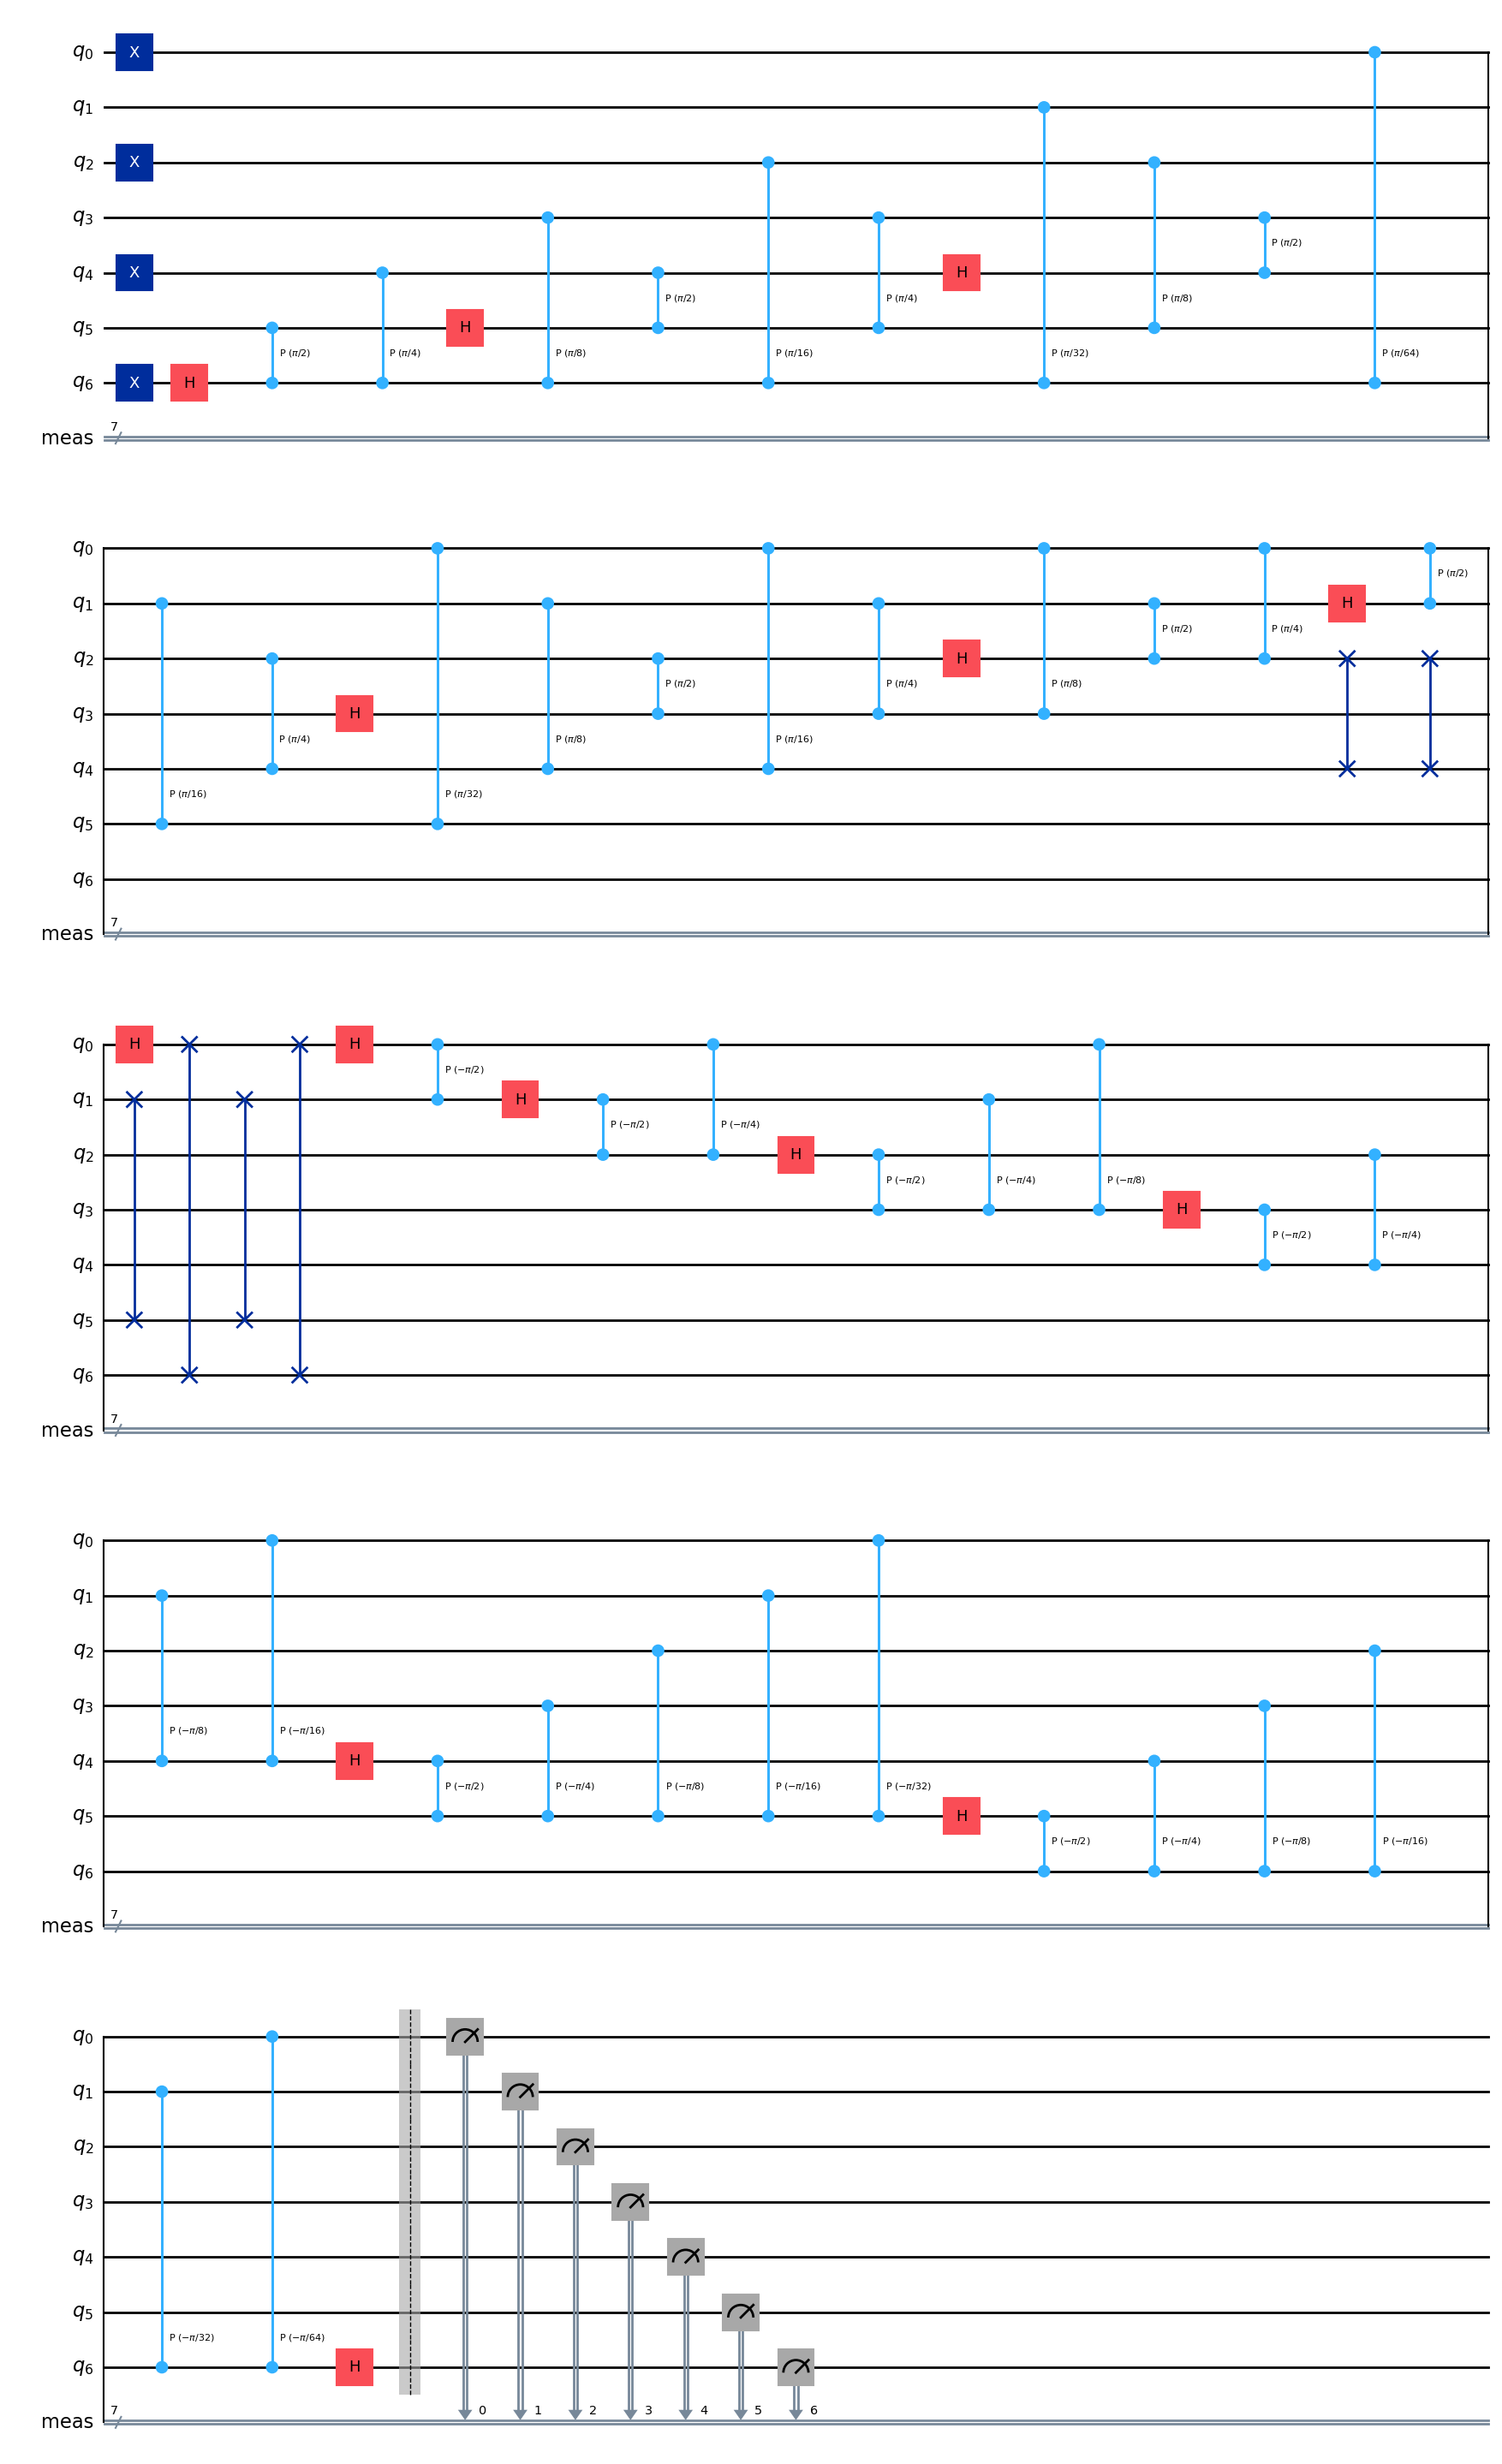

In [50]:
qc = iqft_recursive(qc, len(val))
qc.measure_all()
qc.draw("mpl")

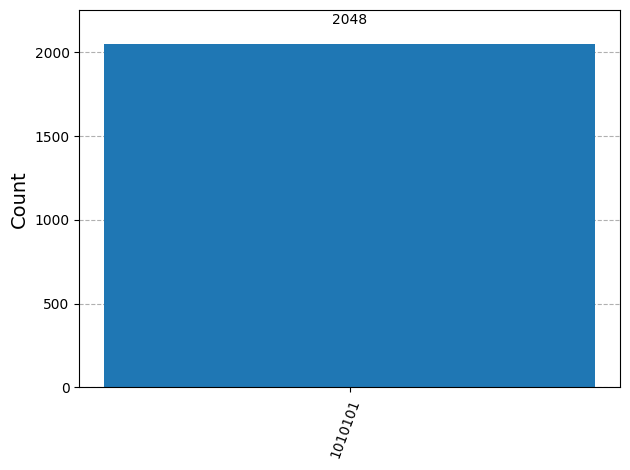

In [51]:
backend = Aer.get_backend("qasm_simulator")
shots = 2048
transpiled_qc = transpile(qc, backend, optimization_level=3)
job = backend.run(transpiled_qc, shots=shots)
counts = job.result().get_counts()
plot_histogram(counts)

### Qubit |11111101>

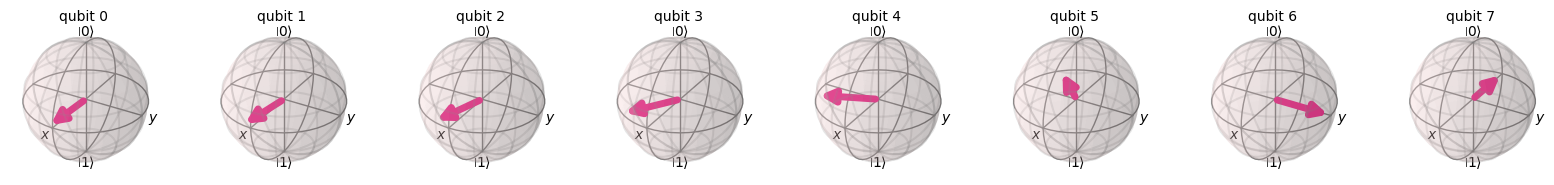

In [52]:
val = "11111101"
qc = encode_qunatum(val)
qc = qft_recursive(qc, len(val))
statevector = get_state_bloch(qc)
plot_bloch_multivector(statevector)

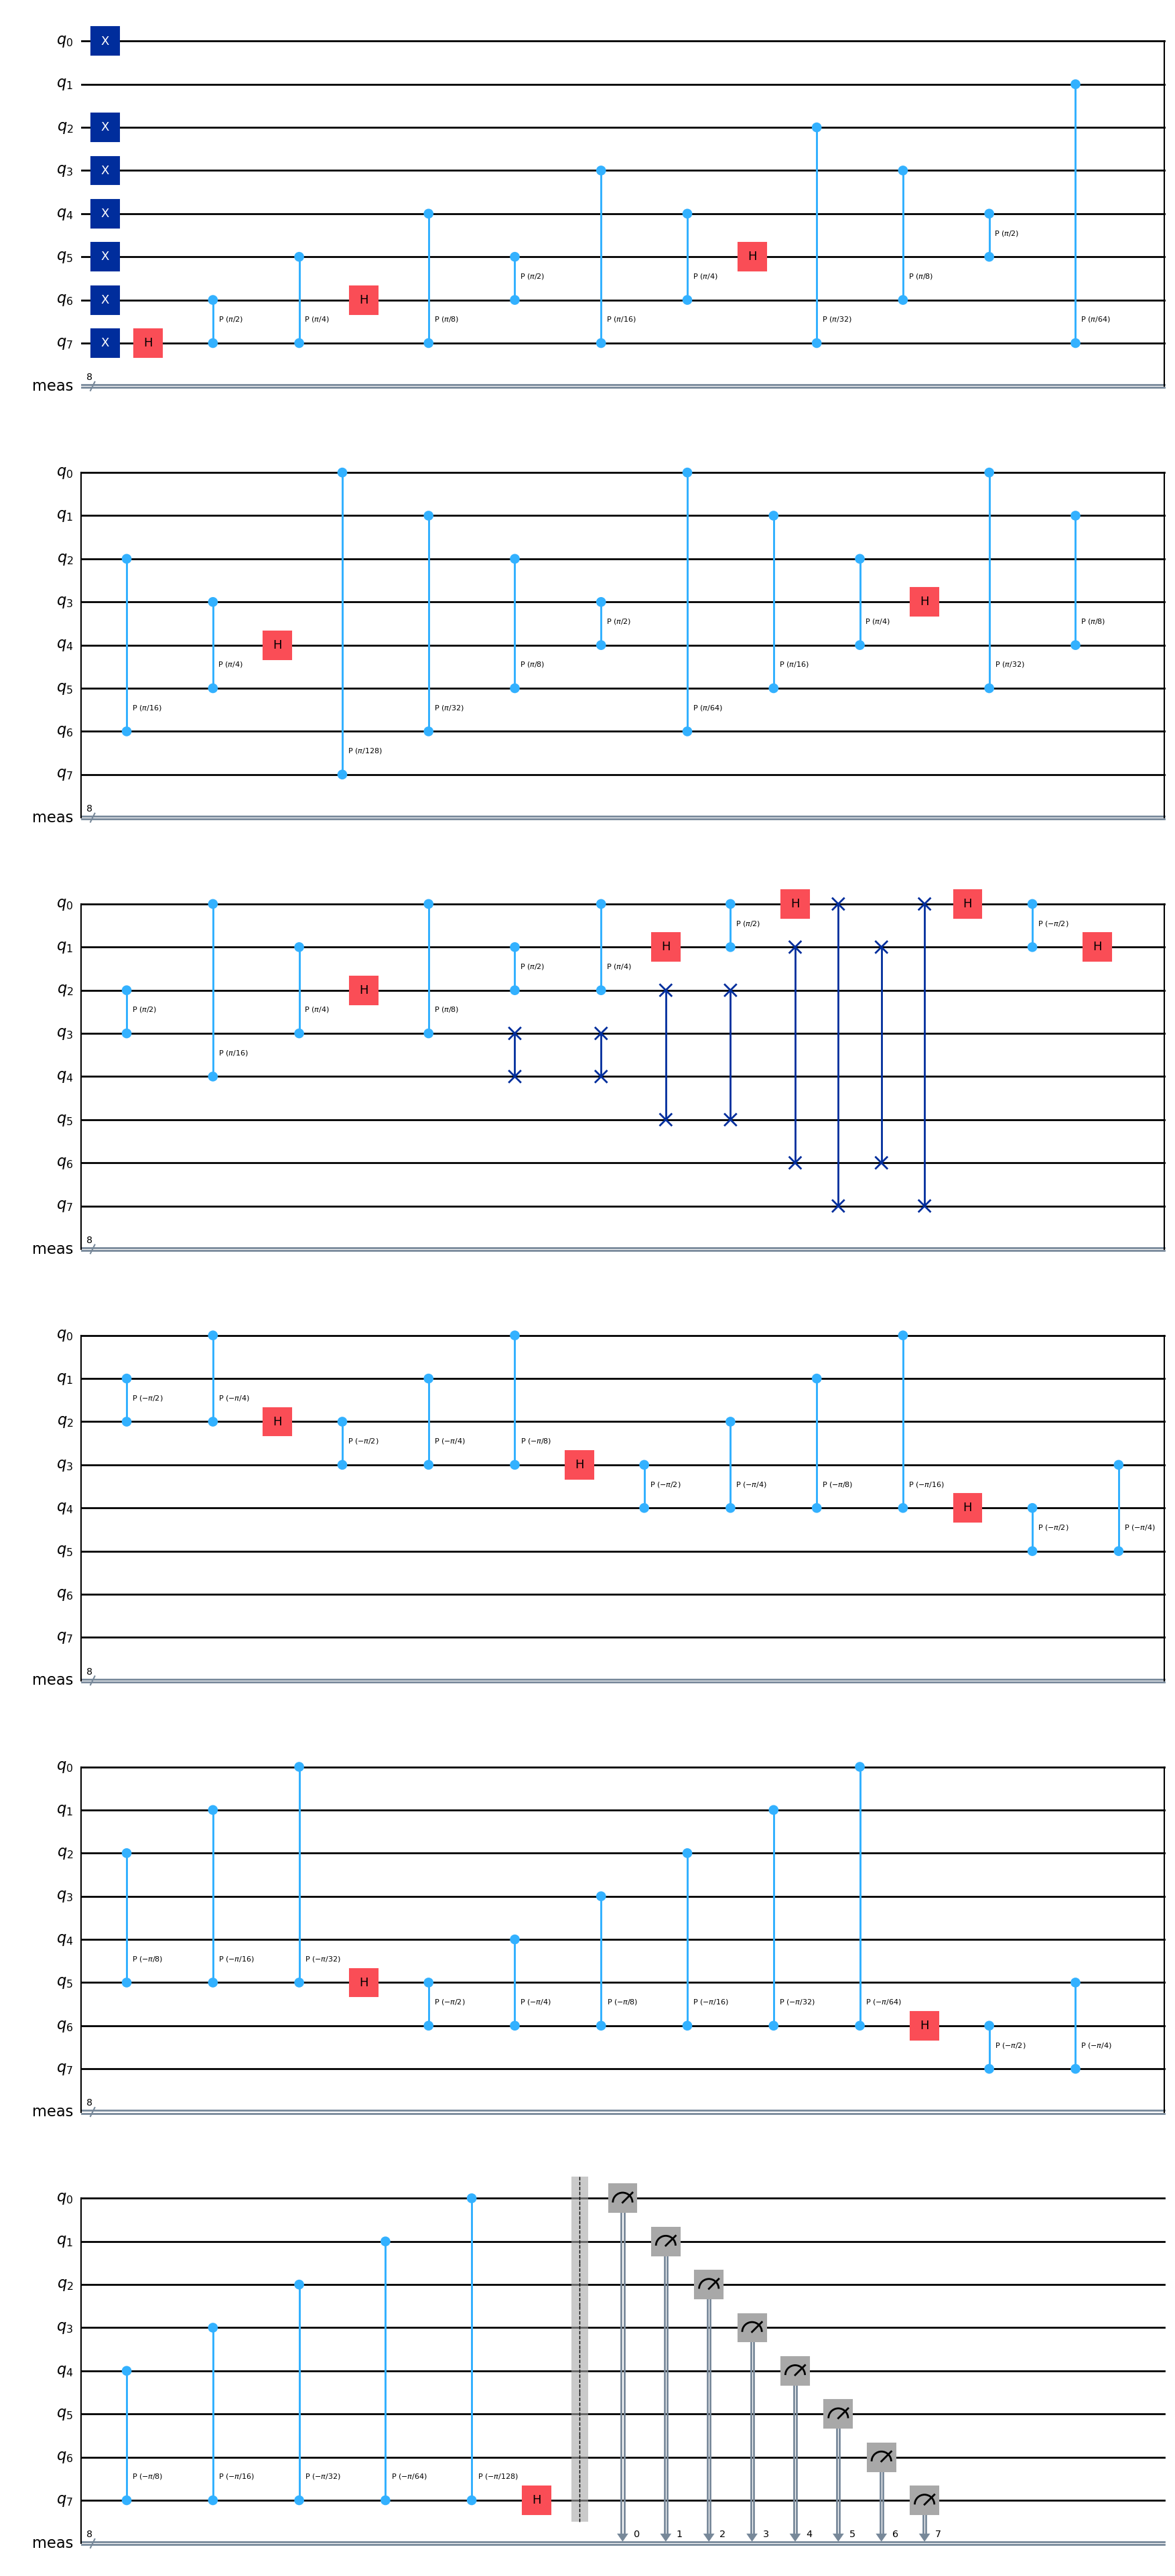

In [53]:
qc = iqft_recursive(qc, len(val))
qc.measure_all()
qc.draw("mpl")

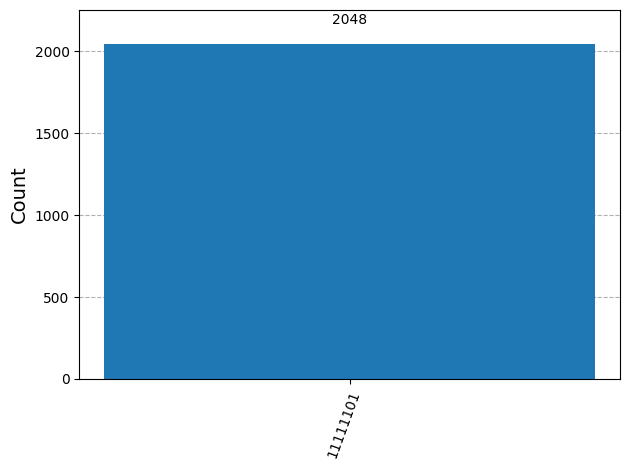

In [54]:
backend = Aer.get_backend("qasm_simulator")
shots = 2048
transpiled_qc = transpile(qc, backend, optimization_level=3)
job = backend.run(transpiled_qc, shots=shots)
counts = job.result().get_counts()
plot_histogram(counts)

## Conclusions

In this laboratory, the Quantum Fourier Transform (QFT) and its inverse (IQFT) were studied and implemented for multi-qubit systems. The QFT was shown to transform quantum states from the computational basis into the Fourier basis by encoding numerical values into relative phase rotations using Hadamard and controlled phase gates. The inverse QFT was implemented by reversing the gate order and applying opposite phase rotations, successfully recovering the original computational basis states. Simulations using Qiskit and Bloch sphere visualizations confirmed the correctness of both transformations and demonstrated that IQFT is the exact inverse of QFT.